In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import export_text
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore") 

In [2]:
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218909 sha256=19f82bb4e3f1851b9631cf36bd7a2b52f78f9185fdda7ec89def0f762bdfd6b7
  Stored in directory: /root/.cache/pip/wheels/7f/33/8b/50b245c5c65433cd8f5cb24ac15d97e5a3db2d41a8b6ae957d
Successfully built pandas_ta


In [3]:
data = pd.read_csv('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')
data.head()

,Date,Open,High,Low,Close,Volume
0,15.08.2017 00:00:00.000,1.17786,1.17812,1.17750,1.17759,6070.48
1,15.08.2017 01:00:00.000,1.17759,1.17802,1.17752,1.17783,3163.99
2,15.08.2017 02:00:00.000,1.17783,1.17802,1.17682,1.17755,4086.81
3,15.08.2017 03:00:00.000,1.17757,1.17895,1.17751,1.17811,6937.33
4,15.08.2017 04:00:00.000,1.17812,1.17928,1.17812,1.17855,7265.10


In [4]:
import pandas_ta as ta
data['RSI'] = ta.rsi(data['Close'], length=14)
data['sma10'] = ta.sma(data['Close'], length=10)
data['sma50'] = ta.sma(data['Close'], length=50)
macd = ta.macd(data['Close'], fast=12, slow=26, signal=9)
data['macd_line'] = macd['MACD_12_26_9']
data['macd_signal'] = macd['MACDs_12_26_9']
data['macd_diff'] = data['macd_line'] - data['macd_signal']
data['sma_diff'] = data['sma50'] - data['sma10']

    # پارامترها
window_size = 10
profit_threshold = 0.001  # آستانه 0.1%

    # محاسبه حداکثر High و حداقل Low در 10 کندل آینده
data['Future_Max_High'] = data['High'].rolling(window=window_size, closed='right').max().shift(-window_size)
data['Future_Min_Low'] = data['Low'].rolling(window=window_size, closed='right').min().shift(-window_size)

    # محاسبه تغییرات نسبی
data['Max_High_Diff'] = (data['Future_Max_High'] - data['Close']) / data['Close']
data['Min_Low_Diff'] = (data['Future_Min_Low'] - data['Close']) / data['Close']

    # 1. سیگنال‌های عادی (فقط بر اساس آستانه)
data['Signal_Threshold'] = 'hold'
data.loc[data['Max_High_Diff'] >= profit_threshold, 'Signal_Threshold'] = 'buy'
data.loc[data['Min_Low_Diff'] <= -profit_threshold, 'Signal_Threshold'] = 'sell'

    # 2. تشخیص تقاطع MACD
data['MACD_Crossover_Buy'] = (data['macd_line'] > data['macd_signal']) & (data['macd_line'].shift(1) < data['macd_signal'].shift(1))
data['MACD_Crossover_Sell'] = (data['macd_line'] < data['macd_signal']) & (data['macd_line'].shift(1) > data['macd_signal'].shift(1))

    # 3. سیگنال‌های نهایی (آستانه + MACD Crossover یا RSI)
data['Signal_Final'] = 'hold'
buy_condition = (data['Signal_Threshold'] == 'buy') & ((data['MACD_Crossover_Buy']) | (data['RSI'] < 35))
sell_condition = (data['Signal_Threshold'] == 'sell') & ((data['MACD_Crossover_Sell']) | (data['RSI'] > 65))
data.loc[buy_condition, 'Signal_Final'] = 'buy'
data.loc[sell_condition, 'Signal_Final'] = 'sell'

    # حذف NaNها
data.dropna(inplace=True)

In [5]:
data.head()

,Date,Open,High,Low,Close,Volume,RSI,sma10,sma50,macd_line,...,macd_diff,sma_diff,Future_Max_High,Future_Min_Low,Max_High_Diff,Min_Low_Diff,Signal_Threshold,MACD_Crossover_Buy,MACD_Crossover_Sell,Signal_Final
49,17.08.2017 01:00:00.000,1.17712,1.17793,1.17705,1.17776,3865.97,67.299652,1.173869,1.174137,0.000717,...,0.000900,0.000268,1.17899,1.17300,0.001044,-0.004042,sell,False,False,sell
50,17.08.2017 02:00:00.000,1.17772,1.17791,1.17698,1.17737,3134.37,65.033882,1.174659,1.174132,0.000880,...,0.000850,-0.000527,1.17899,1.17038,0.001376,-0.005937,sell,False,False,sell
51,17.08.2017 03:00:00.000,1.17737,1.17745,1.17649,1.17679,6088.52,61.706650,1.175311,1.174112,0.000950,...,0.000736,-0.001199,1.17899,1.16903,0.001869,-0.006594,sell,False,False,hold
52,17.08.2017 04:00:00.000,1.17679,1.17888,1.17669,1.17885,9345.45,67.973832,1.176179,1.174138,0.001159,...,0.000756,-0.002041,1.17899,1.16622,0.000119,-0.010714,sell,False,False,sell
53,17.08.2017 05:00:00.000,1.17885,1.17899,1.17775,1.17824,7011.27,64.602175,1.176989,1.174140,0.001261,...,0.000686,-0.002849,1.17896,1.16622,0.000611,-0.010202,sell,False,False,hold


In [6]:
data['Signal_Final'] = data['Signal_Final'].map({'buy': 2, 'sell': 0, 'hold': 1})

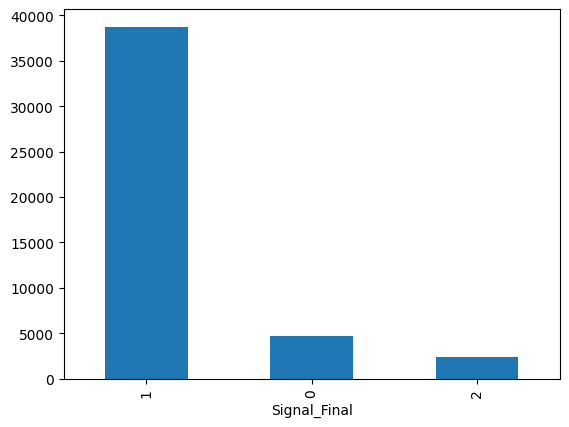

In [9]:
import matplotlib.pyplot as plt
data['Signal_Final'].value_counts(dropna=False).plot(kind='bar')
plt.show()

In [10]:
data['Signal_Final'].value_counts(dropna=False)

Signal_Final
1    38759
0     4669
2     2378
Name: count, dtype: int64

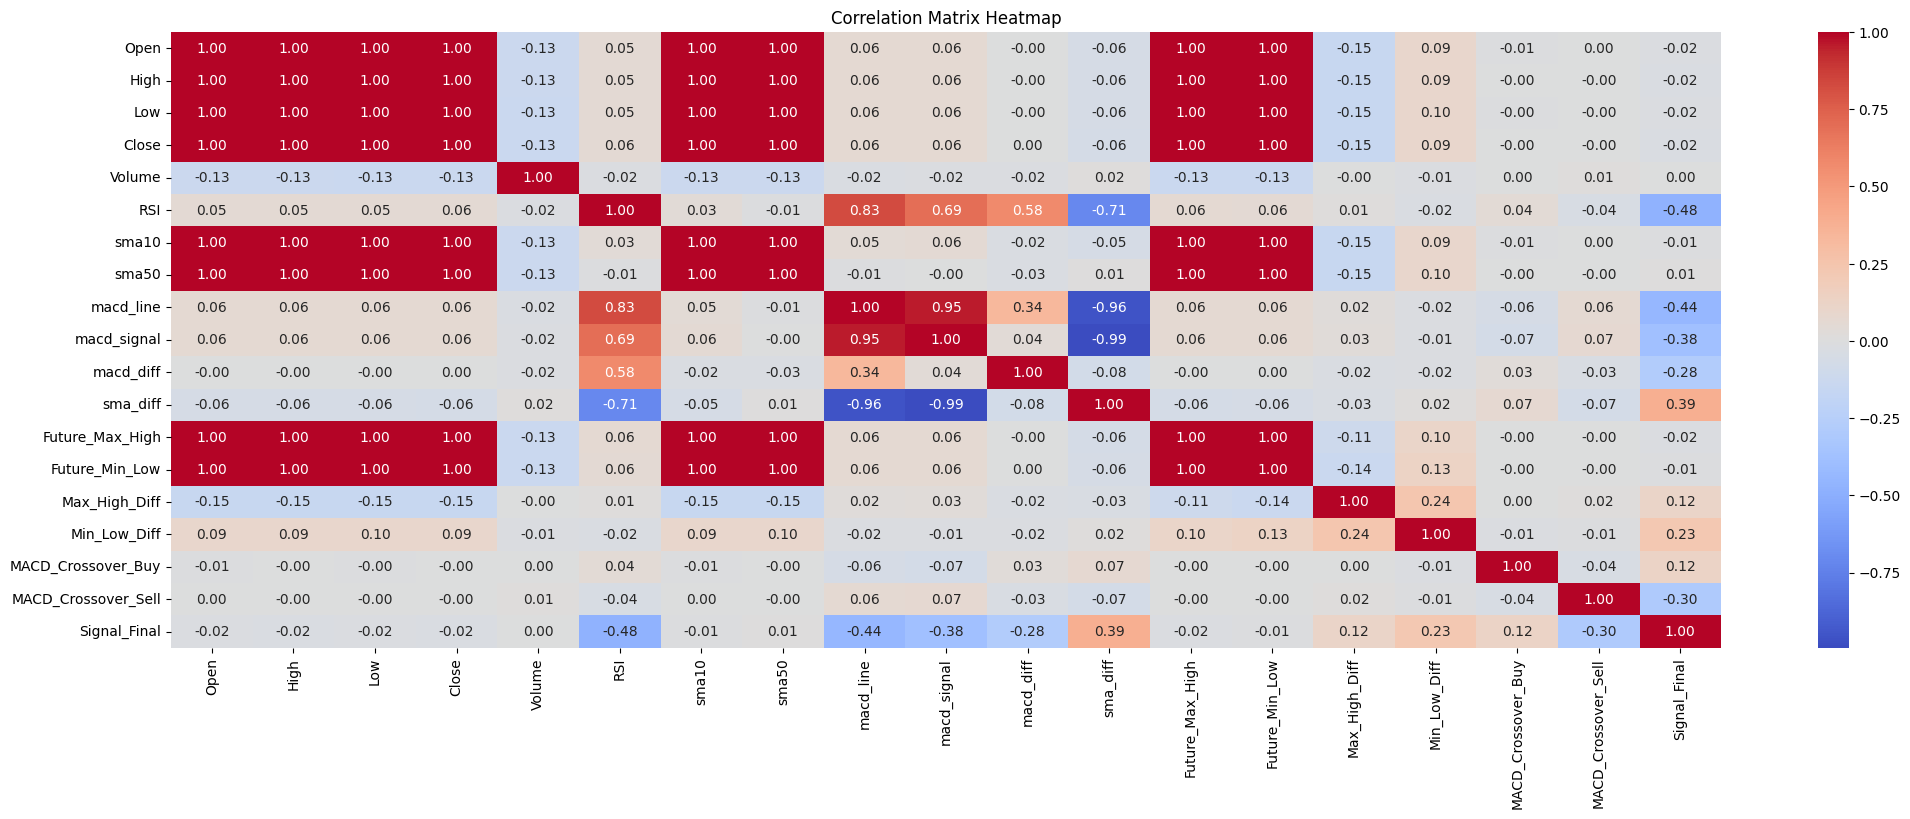

In [11]:
import seaborn as sns

correlation_matrix = data.drop(['Date','Signal_Threshold'],axis=1).corr()
plt.figure(figsize=(25, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [12]:
features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 'macd_diff', 'sma_diff','MACD_Crossover_Buy', 'MACD_Crossover_Sell']

# features = ['RSI', 'sma10', 'sma50']
X = data[features]
y = data['Signal_Final']

# تقسیم داده‌ها به مجموعه آموزش و تست (80% آموزش، 20% تست)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)

In [13]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)  # عمق محدود برای قوانین ساده
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [14]:
rules = export_text(tree, feature_names=features)
print("قوانین استخراج‌شده از Decision Tree:")
print(rules)

قوانین استخراج‌شده از Decision Tree:
|--- RSI <= 65.00
|   |--- MACD_Crossover_Sell <= 0.50
|   |   |--- RSI <= 34.98
|   |   |   |--- macd_signal <= -0.00
|   |   |   |   |--- RSI <= 34.69
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- RSI >  34.69
|   |   |   |   |   |--- class: 2
|   |   |   |--- macd_signal >  -0.00
|   |   |   |   |--- macd_line <= -0.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- macd_line >  -0.00
|   |   |   |   |   |--- class: 1
|   |   |--- RSI >  34.98
|   |   |   |--- MACD_Crossover_Buy <= 0.50
|   |   |   |   |--- RSI <= 35.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- RSI >  35.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- MACD_Crossover_Buy >  0.50
|   |   |   |   |--- RSI <= 45.43
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- RSI >  45.43
|   |   |   |   |   |--- class: 1
|   |--- MACD_Crossover_Sell >  0.50
|   |   |--- RSI <= 35.00
|   |   |   |--- macd_diff <= -0.00
|   |   |   |   |--- class: 0
|   |  

In [15]:
from sklearn.metrics import classification_report
y_pred = tree.predict(X_test)
print("\nگزارش عملکرد مدل:")
print(classification_report(y_test, y_pred))


گزارش عملکرد مدل:
              precision    recall  f1-score   support

           0       0.62      0.97      0.76       867
           1       0.94      0.94      0.94      7784
           2       0.50      0.01      0.01       511

    accuracy                           0.89      9162
   macro avg       0.69      0.64      0.57      9162
weighted avg       0.88      0.89      0.87      9162



In [16]:
# نمایش اهمیت ویژگی‌ها
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': tree.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
               Feature  Importance
1                  RSI    0.714217
9  MACD_Crossover_Sell    0.223987
8   MACD_Crossover_Buy    0.040177
3                sma50    0.009887
5          macd_signal    0.005440
6            macd_diff    0.003599
4            macd_line    0.002082
7             sma_diff    0.000609
0                Close    0.000000
2                sma10    0.000000


In [7]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt

def test_model_and_plot(csv_path,model):
    # خواندن دیتاست از فایل CSV
    data = pd.read_csv(csv_path)

    # بررسی مقادیر نامعتبر در ستون Close
    if not data['Close'].replace([np.inf, -np.inf], np.nan).notnull().all():
        print("Warning: Invalid values (inf or NaN) found in 'Close' column. Replacing with NaN...")
        data['Close'].replace([np.inf, -np.inf], np.nan, inplace=True)

    data['RSI'] = ta.rsi(data['Close'], length=14)
    data['sma10'] = ta.sma(data['Close'], length=10)
    data['sma50'] = ta.sma(data['Close'], length=50)
    macd = ta.macd(data['Close'], fast=12, slow=26, signal=9)
    data['macd_line'] = macd['MACD_12_26_9']
    data['macd_signal'] = macd['MACDs_12_26_9']
    data['macd_diff'] = data['macd_line'] - data['macd_signal']
    data['sma_diff'] = data['sma50'] - data['sma10']
    
        # پارامترها
    window_size = 10
    profit_threshold = 0.001  # آستانه 0.1%
    
        # محاسبه حداکثر High و حداقل Low در 10 کندل آینده
    data['Future_Max_High'] = data['High'].rolling(window=window_size, closed='right').max().shift(-window_size)
    data['Future_Min_Low'] = data['Low'].rolling(window=window_size, closed='right').min().shift(-window_size)
    
        # محاسبه تغییرات نسبی
    data['Max_High_Diff'] = (data['Future_Max_High'] - data['Close']) / data['Close']
    data['Min_Low_Diff'] = (data['Future_Min_Low'] - data['Close']) / data['Close']
    
        # 1. سیگنال‌های عادی (فقط بر اساس آستانه)
    data['Signal_Threshold'] = 'hold'
    data.loc[data['Max_High_Diff'] >= profit_threshold, 'Signal_Threshold'] = 'buy'
    data.loc[data['Min_Low_Diff'] <= -profit_threshold, 'Signal_Threshold'] = 'sell'
    
        # 2. تشخیص تقاطع MACD
    data['MACD_Crossover_Buy'] = (data['macd_line'] > data['macd_signal']) & (data['macd_line'].shift(1) < data['macd_signal'].shift(1))
    data['MACD_Crossover_Sell'] = (data['macd_line'] < data['macd_signal']) & (data['macd_line'].shift(1) > data['macd_signal'].shift(1))
    
        # حذف NaNها
    data.dropna(inplace=True)

    features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 'macd_diff', 'sma_diff','MACD_Crossover_Buy', 'MACD_Crossover_Sell']

    # features = ['RSI', 'sma10', 'sma50']
    X = data[features]

    # پیش‌بینی سیگنال‌ها
    data['predicted_Signal'] = model.predict(X)

    # انتخاب 5 دسته 100تایی متوالی به صورت رندوم
    max_start = len(data) - 100
    random_starts = np.random.choice(range(max_start), size=5, replace=False)

    # رسم 5 نمودار
    for i, start in enumerate(random_starts):
        end = start + 100
        subset = data.iloc[start:end]

        # ایجاد زیرنمودارها (3 ردیف: قیمت، RSI، MACD)
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, 
                                             gridspec_kw={'height_ratios': [2, 1, 1], 'hspace': 0.05})

        # نمودار قیمت و EMA
        ax1.plot(subset.index, subset['Close'], label='Close Price', color='black')
        ax1.plot(subset.index, subset['sma10'], label='sma10', color='blue')
        ax1.plot(subset.index, subset['sma50'], label='sma50', color='orange')

        # رسم سیگنال‌ها با مثلث
        buy_Signals = subset[subset['predicted_Signal'] == 2]  # Buy
        sell_Signals = subset[subset['predicted_Signal'] == 0]  # Sell

        ax1.scatter(buy_Signals.index, buy_Signals['Close'], marker='^', color='green', label='Buy', s=100)
        ax1.scatter(sell_Signals.index, sell_Signals['Close'], marker='v', color='red', label='Sell', s=100)

        ax1.set_title(f'Close Price, EMA, RSI, MACD, and Predicted Signals (Sample {i+1})')
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.grid(True)

        # نمودار RSI
        ax2.plot(subset.index, subset['RSI'], label='RSI', color='purple')
        ax2.axhline(y=70, color='red', linestyle='--')
        ax2.axhline(y=30, color='green', linestyle='--')
        ax2.set_ylabel('RSI')
        ax2.legend()
        ax2.grid(True)

        # نمودار MACD
        ax3.plot(subset.index, subset['macd_line'], label='MACD Line', color='blue')
        ax3.plot(subset.index, subset['macd_signal'], label='MACD Signal', color='orange')
        ax3.set_xlabel('Index')
        ax3.set_ylabel('MACD')
        ax3.legend()
        ax3.grid(True)

        plt.show()


    print("Plots saved as 'Signal_plot_1.png' to 'Signal_plot_5.png'. You can download them from Kaggle output.")

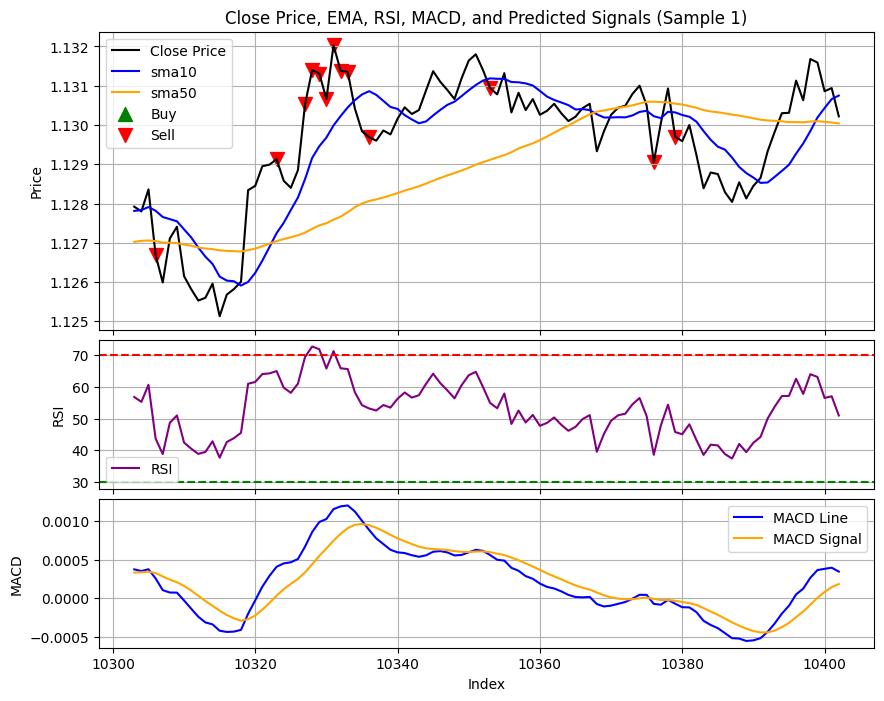

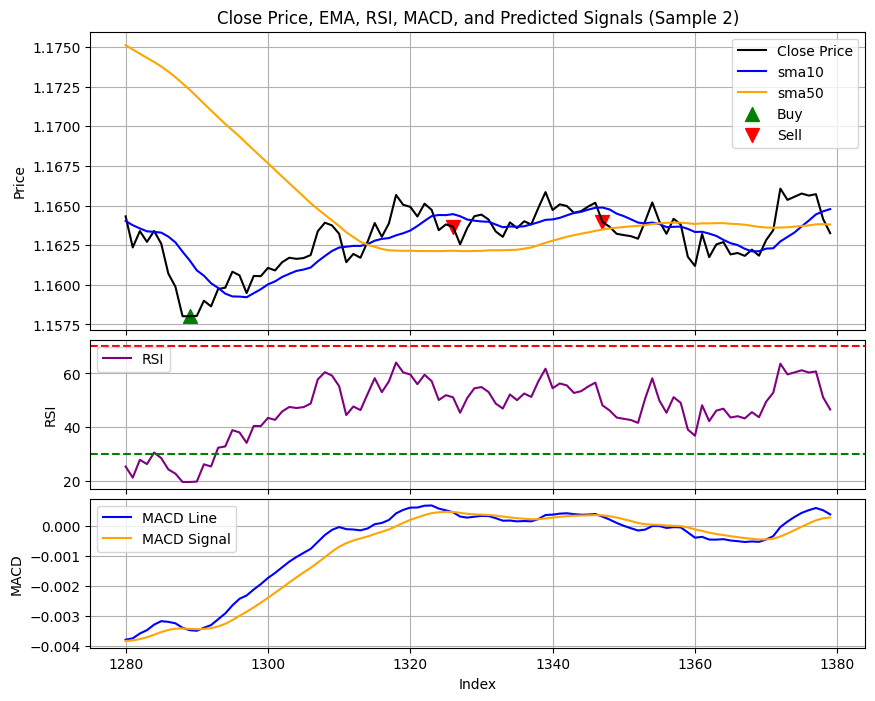

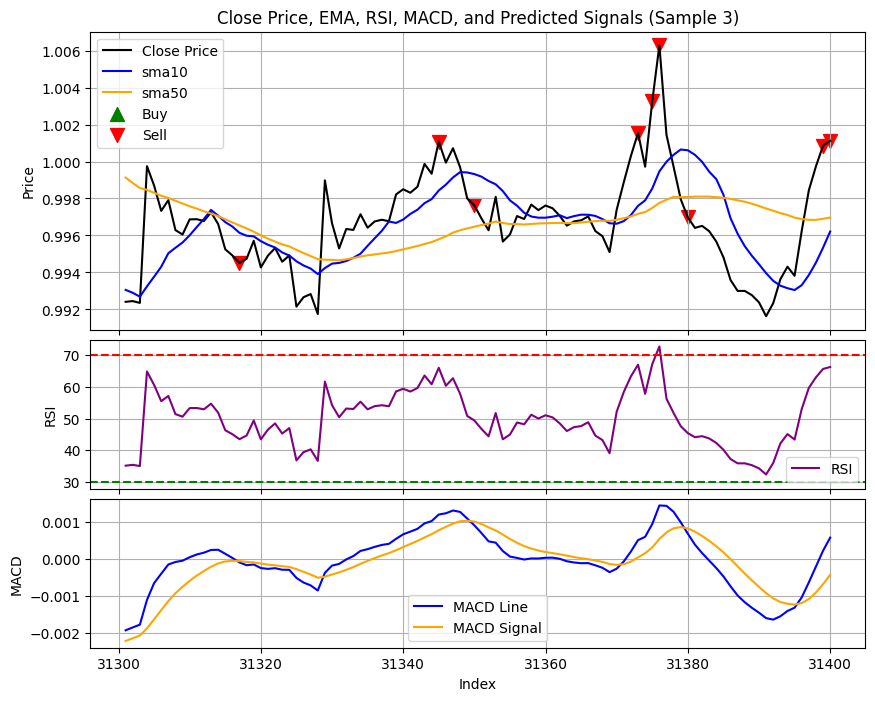

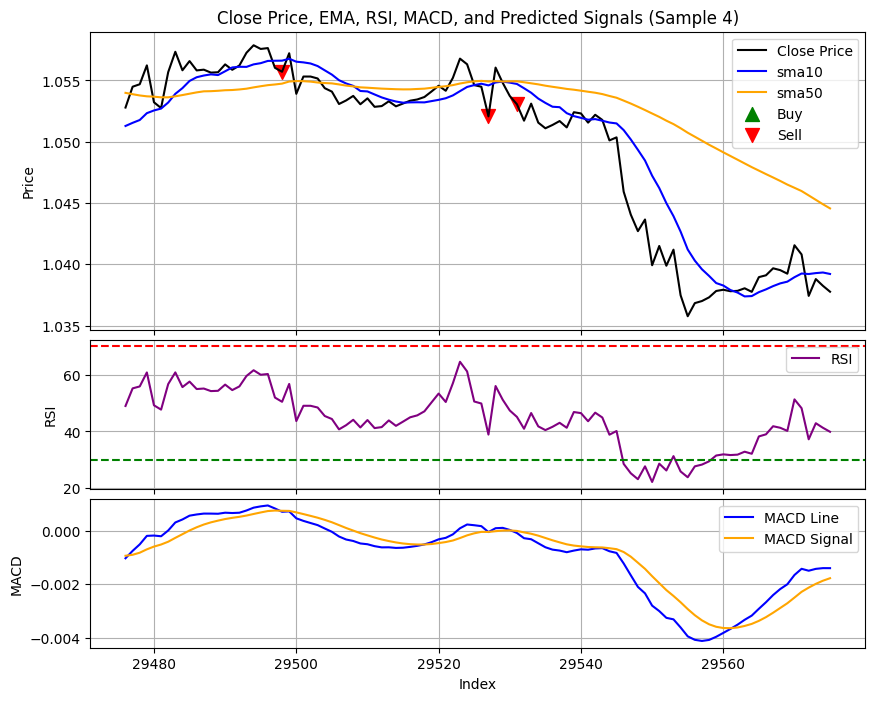

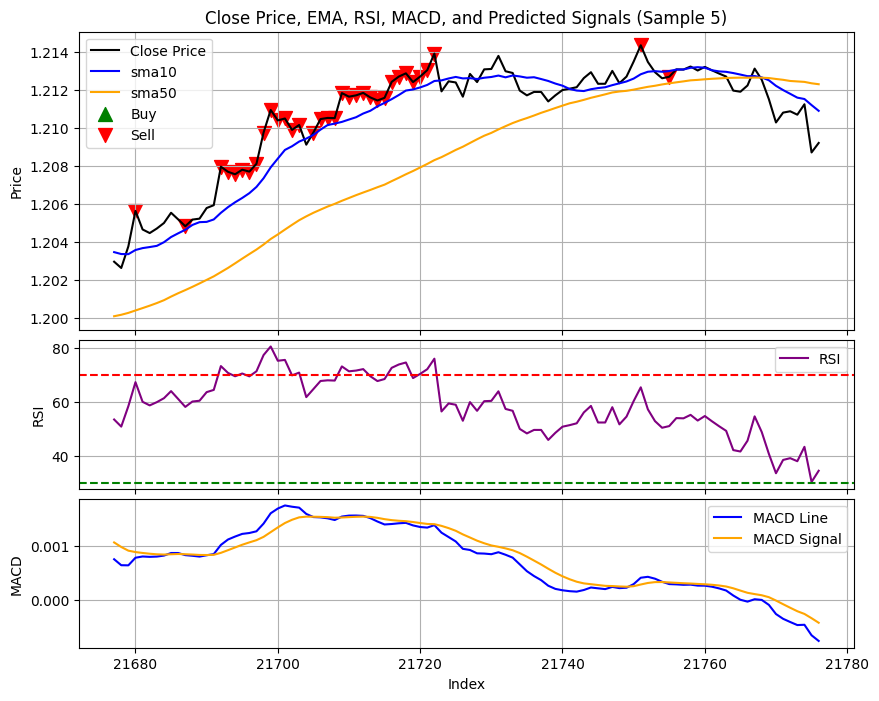

Plots saved as 'Signal_plot_1.png' to 'Signal_plot_5.png'. You can download them from Kaggle output.


In [18]:
test_model_and_plot('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv',tree)

In [8]:
features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 'macd_diff', 'sma_diff','MACD_Crossover_Buy', 'MACD_Crossover_Sell']

X = data[features]
y = data['Signal_Final']

In [20]:


# تقسیم داده‌ها به مجموعه آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

In [22]:
from sklearn.metrics import accuracy_score
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Sell (-1)', 'Hold (0)', 'Buy (1)']))

Accuracy: 0.9062

Classification Report:
              precision    recall  f1-score   support

   Sell (-1)       0.71      0.87      0.78       912
    Hold (0)       0.94      0.95      0.95      7767
     Buy (1)       0.60      0.20      0.30       483

    accuracy                           0.91      9162
   macro avg       0.75      0.68      0.68      9162
weighted avg       0.90      0.91      0.90      9162



In [23]:
# نمایش اهمیت ویژگی‌ها
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
               Feature  Importance
9  MACD_Crossover_Sell    0.532634
8   MACD_Crossover_Buy    0.223998
1                  RSI    0.166992
3                sma50    0.012480
4            macd_line    0.012477
0                Close    0.011348
2                sma10    0.010958
5          macd_signal    0.010599
6            macd_diff    0.009751
7             sma_diff    0.008764


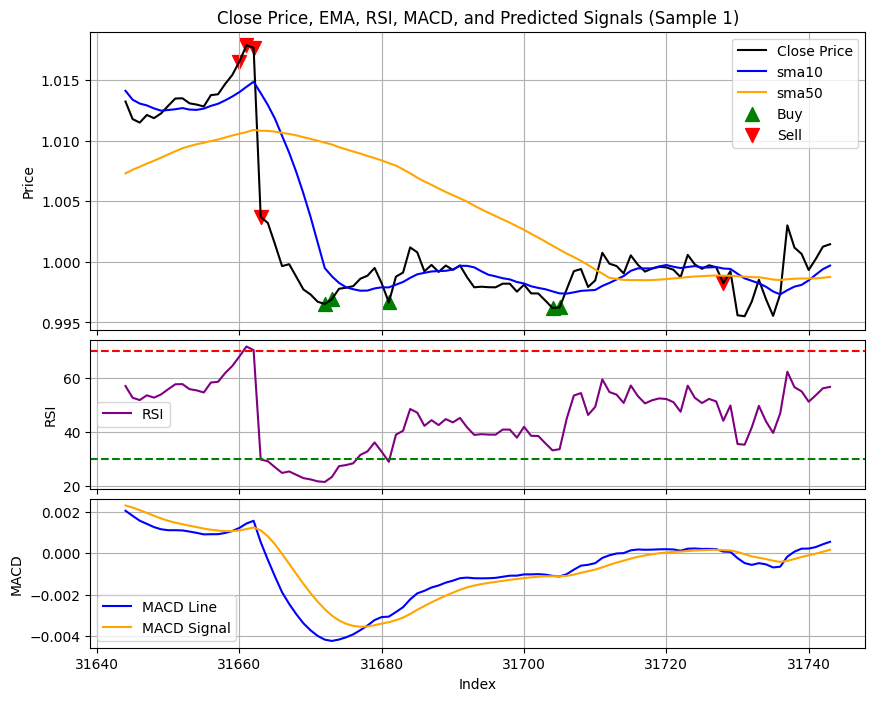

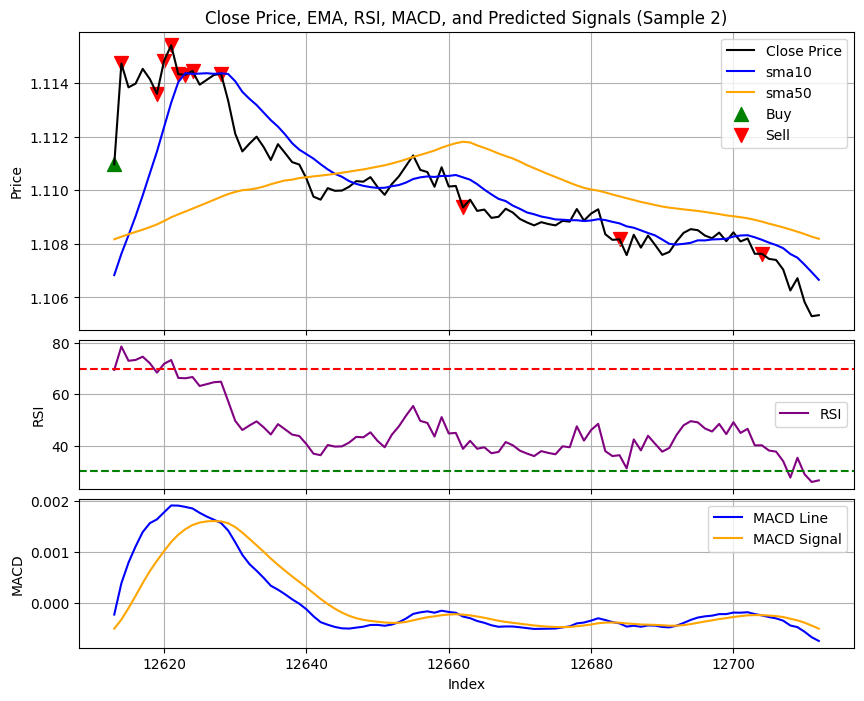

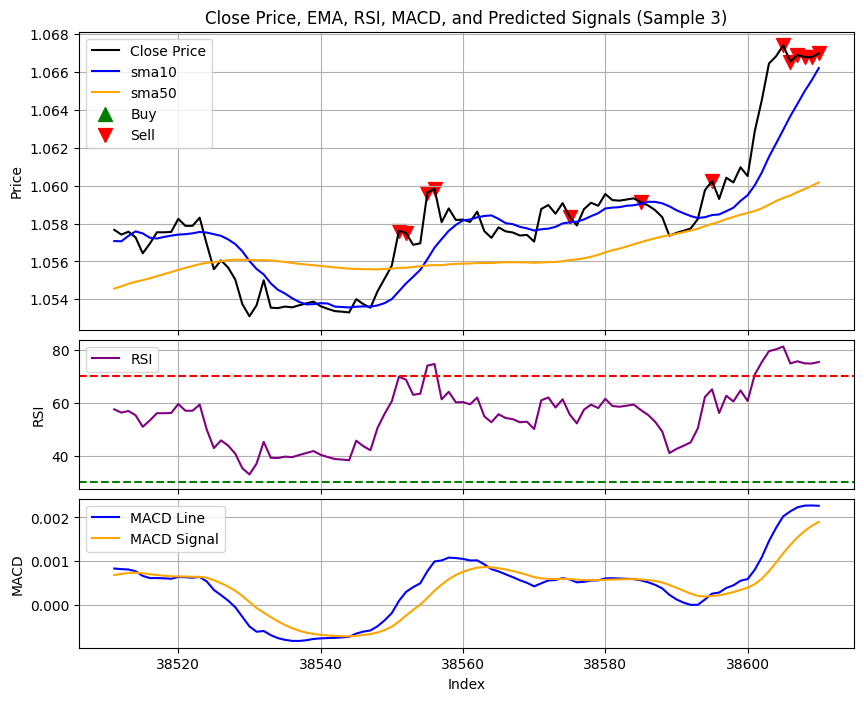

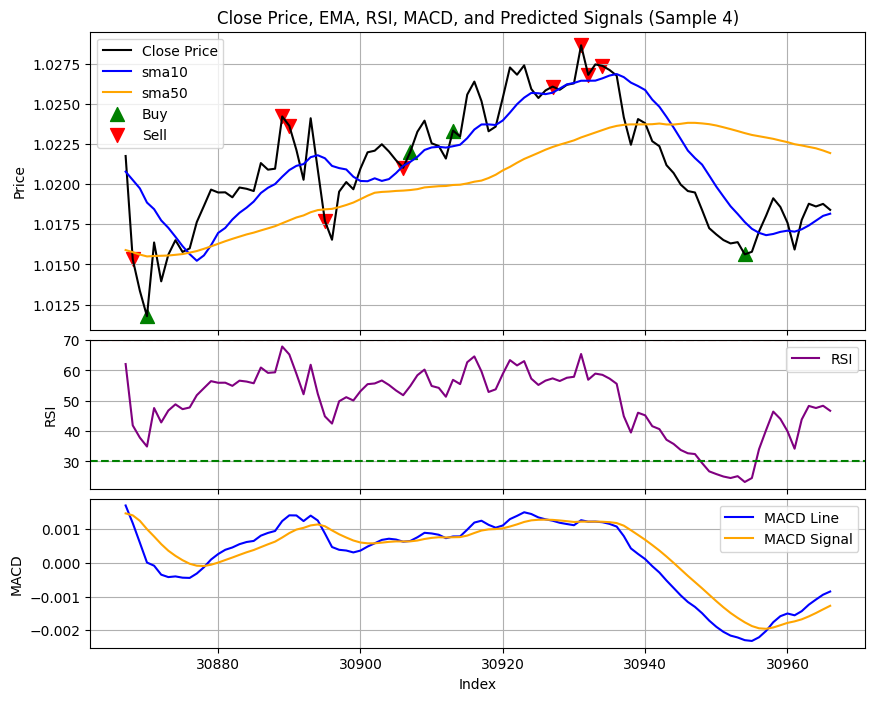

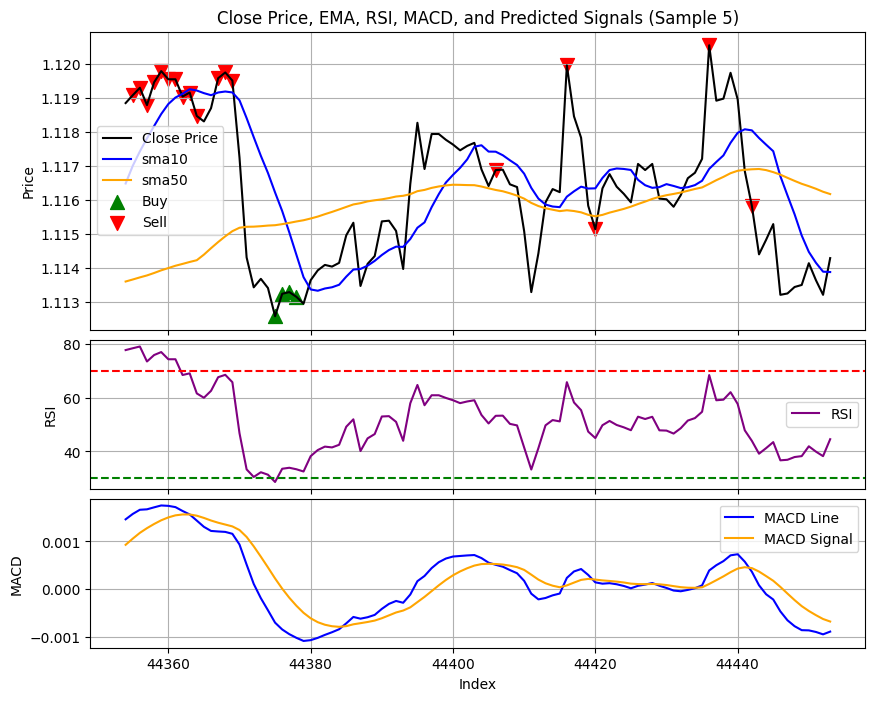

Plots saved as 'Signal_plot_1.png' to 'Signal_plot_5.png'. You can download them from Kaggle output.


In [24]:
test_model_and_plot('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv',xgb_model)

In [ ]:


# فرض می‌کنیم داده‌ها آماده هستند (X و y از قبل تعریف شده‌اند)
# تقسیم داده‌ها به آموزش، اعتبارسنجی، و تست


# نرمال‌سازی ویژگی‌ها


# ساخت مدل MLP با TensorFlow
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

# کامپایل مدل
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# وزن‌دهی به کلاس‌ها برای مدیریت عدم توازن
class_weights = {0: len(y_train) / (3 * sum(y_train == 0)), 
                 1: len(y_train) / (3 * sum(y_train == 1)), 
                 2: len(y_train) / (3 * sum(y_train == 2))}

# آموزش مدل
history = model.fit(X_train_scaled, y_train_onehot, 
                    epochs=50, 
                    batch_size=32, 
                    validation_data=(X_val_scaled, y_val_onehot), 
                    class_weight=class_weights, 
                    verbose=1)

# ارزیابی مدل
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_onehot, verbose=0)
print(f"\nدقت مدل روی مجموعه تست: {test_accuracy:.4f}")

# گزارش عملکرد
y_test_pred = model.predict(X_test_scaled).argmax(axis=1)
print("\nگزارش عملکرد مدل روی مجموعه تست:")
print(classification_report(y_test, y_test_pred, target_names=['sell (0)', 'hold (1)', 'buy (2)']))

# رسم نمودار Loss و Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 'macd_diff', 'sma_diff','MACD_Crossover_Buy', 'MACD_Crossover_Sell']

X = data[features]
y = data['Signal_Final']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=False)

2025-04-21 12:12:16.428742: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745237536.625195      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745237536.683467      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# تبدیل برچسب‌ها به One-Hot Encoding
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=3)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=3)

In [15]:
del model

In [16]:
# model = Sequential([
#     Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
#     Dropout(0.3),
#     Dense(64, activation='relu'),
#     Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dense(3, activation='softmax')
# ])
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

# کامپایل مدل
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy','f1_score'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,363 (13.14 KB)

 Trainable params: 3,363 (13.14 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
class_weights = {0: len(y_train) / (3 * sum(y_train == 0)), 
                 1: len(y_train) / (3 * sum(y_train == 1)), 
                 2: len(y_train) / (3 * sum(y_train == 2))}

# # آموزش مدل
history = model.fit(X_train_scaled, y_train_onehot, 
                    epochs=100, 
                    batch_size=32, 
                    validation_data=(X_val_scaled, y_val_onehot), 
                    class_weight=class_weights, 
                    verbose=1)

Epoch 1/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5784 - f1_score: 0.4701 - loss: 0.6483 - val_accuracy: 0.7779 - val_f1_score: 0.6575 - val_loss: 0.5011
Epoch 2/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7414 - f1_score: 0.6164 - loss: 0.3827 - val_accuracy: 0.8326 - val_f1_score: 0.7005 - val_loss: 0.3656
Epoch 3/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7726 - f1_score: 0.6474 - loss: 0.3408 - val_accuracy: 0.7890 - val_f1_score: 0.6751 - val_loss: 0.4390
Epoch 4/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7837 - f1_score: 0.6561 - loss: 0.3198 - val_accuracy: 0.8342 - val_f1_score: 0.7124 - val_loss: 0.3521
Epoch 5/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8020 - f1_score: 0.6785 - loss: 0.2999 - val_accuracy: 0.8212 - val_f1_score: 0.7027 - val_loss: 0.3713
Epoch 6/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7977 - f1_score: 0.6689 - loss: 0.2984 - val_accuracy: 0.7730 - val_f1_score: 

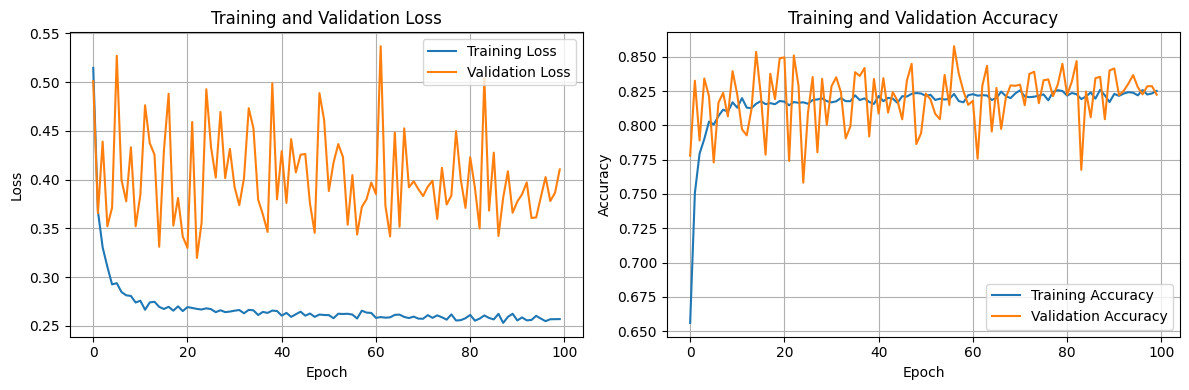

In [18]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
test_loss, test_accuracy, f1 = model.evaluate(X_test_scaled, y_test_onehot, verbose=0)
print(f"\nدقت مدل روی مجموعه تست: {test_accuracy:.4f}")

# گزارش عملکرد
y_test_pred = model.predict(X_test_scaled).argmax(axis=1)
print("\nگزارش عملکرد مدل روی مجموعه تست:")
print(classification_report(y_test, y_test_pred, target_names=['sell (0)', 'hold (1)', 'buy (2)']))


دقت مدل روی مجموعه تست: 0.8207
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

گزارش عملکرد مدل روی مجموعه تست:
              precision    recall  f1-score   support

    sell (0)       0.58      0.99      0.73       867
    hold (1)       1.00      0.79      0.89      7784
     buy (2)       0.32      0.94      0.48       511

    accuracy                           0.82      9162
   macro avg       0.63      0.91      0.70      9162
weighted avg       0.92      0.82      0.85      9162



In [20]:
model.evaluate(X_test_scaled, y_test_onehot, verbose=0)

[0.42819395661354065,
 0.820672333240509,
 <tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.7322264 , 0.88513315, 0.4763799 ], dtype=float32)>]

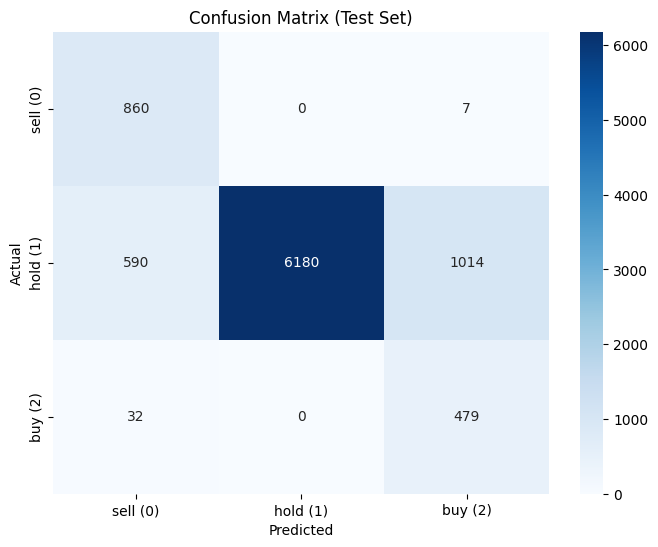

In [21]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_test_pred)

# رسم ماتریس درهم‌ریختگی
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['sell (0)', 'hold (1)', 'buy (2)'], 
            yticklabels=['sell (0)', 'hold (1)', 'buy (2)'])
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

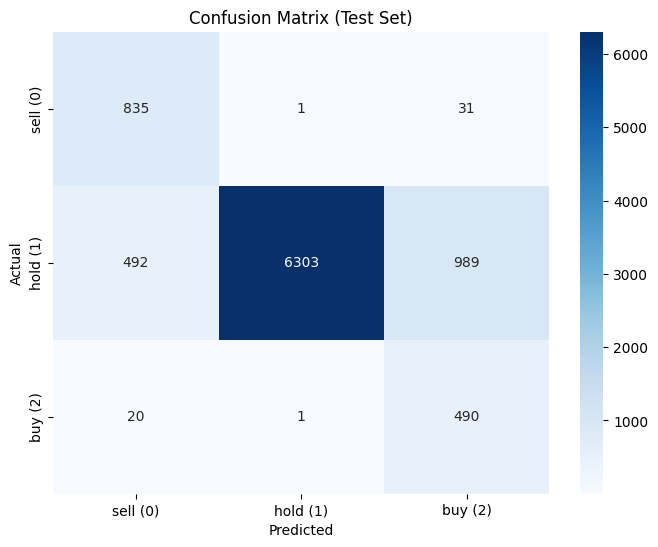

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_test_pred)

# رسم ماتریس درهم‌ریختگی
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['sell (0)', 'hold (1)', 'buy (2)'], 
            yticklabels=['sell (0)', 'hold (1)', 'buy (2)'])
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [25]:
y_test_prob = model.predict(X_test_scaled)
y_test_pred_adjusted = np.zeros_like(y_test_prob.argmax(axis=1))
for i in range(len(y_test_prob)):
    if y_test_prob[i, 2] > 0.9:  # آستانه بالاتر برای buy
        y_test_pred_adjusted[i] = 2
    elif y_test_prob[i, 0] > 0.2:  # آستانه بالاتر برای sell
        y_test_pred_adjusted[i] = 0
    else:
        y_test_pred_adjusted[i] = 1
print(classification_report(y_test, y_test_pred_adjusted, target_names=['sell (0)', 'hold (1)', 'buy (2)']))

287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

    sell (0)       0.55      1.00      0.71       867
    hold (1)       0.98      0.84      0.90      7784
     buy (2)       0.36      0.62      0.45       511

    accuracy                           0.84      9162
   macro avg       0.63      0.82      0.69      9162
weighted avg       0.90      0.84      0.86      9162



In [51]:
del model_manual_oversample

In [9]:
# فرض می‌کنیم X_train_scaled و y_train از قبل تعریف شده‌اند
# تعداد نمونه‌های هر کلاس در داده‌های آموزش
unique, counts = np.unique(y_train, return_counts=True)
class_counts = dict(zip(unique, counts))
print("توزیع کلاس‌ها قبل از Oversampling:")
print(class_counts)

# Oversampling دستی
# هدف: تعداد نمونه‌های buy (2) و sell (0) را به حدود 80% تعداد hold (1) برسانیم
target_count = int(class_counts[1] * 0.8)  # 80% تعداد hold

# جدا کردن نمونه‌ها برای هر کلاس
mask_sell = y_train == 0
mask_hold = y_train == 1
mask_buy = y_train == 2

X_train_sell = X_train_scaled[mask_sell]
y_train_sell = y_train[mask_sell]
X_train_hold = X_train_scaled[mask_hold]
y_train_hold = y_train[mask_hold]
X_train_buy = X_train_scaled[mask_buy]
y_train_buy = y_train[mask_buy]

# Oversampling برای sell (0)
oversample_factor_sell = target_count // len(X_train_sell)  # چند برابر کردن
X_train_sell_oversampled = np.repeat(X_train_sell, oversample_factor_sell, axis=0)
y_train_sell_oversampled = np.repeat(y_train_sell, oversample_factor_sell)

# Oversampling برای buy (2)
oversample_factor_buy = target_count // len(X_train_buy)
X_train_buy_oversampled = np.repeat(X_train_buy, oversample_factor_buy, axis=0)
y_train_buy_oversampled = np.repeat(y_train_buy, oversample_factor_buy)

# ترکیب داده‌های oversampled با داده‌های اصلی hold
X_train_scaled_resampled = np.concatenate([X_train_sell_oversampled, X_train_hold, X_train_buy_oversampled], axis=0)
y_train_resampled = np.concatenate([y_train_sell_oversampled, y_train_hold, y_train_buy_oversampled], axis=0)

# تبدیل برچسب‌ها به One-Hot Encoding
y_train_onehot_resampled = tf.keras.utils.to_categorical(y_train_resampled, num_classes=3)

# نمایش توزیع جدید
print("توزیع کلاس‌ها بعد از Oversampling:")
unique_resampled, counts_resampled = np.unique(y_train_resampled, return_counts=True)
print(dict(zip(unique_resampled, counts_resampled)))

# ساخت و آموزش مدل
model_manual_oversample = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model_manual_oversample.compile(optimizer='adam', 
                                loss='categorical_crossentropy', 
                                metrics=['accuracy'])
model_manual_oversample.summary()
class_weights = {0: len(y_train) / (3 * sum(y_train == 0)), 
                 1: len(y_train) / (3 * sum(y_train == 1)), 
                 2: len(y_train) / (3 * sum(y_train == 2))}
# آموزش مدل
history = model_manual_oversample.fit(X_train_scaled_resampled, y_train_onehot_resampled, 
                                      epochs=50, 
                                      batch_size=32, 
                                      validation_data=(X_val_scaled, y_val_onehot), 
                                      class_weight=class_weights, 
                                      verbose=1)

# ارزیابی مدل
y_test_pred = model_manual_oversample.predict(X_test_scaled).argmax(axis=1)
print("\nگزارش عملکرد مدل روی مجموعه تست:")
print(classification_report(y_test, y_test_pred, target_names=['sell (0)', 'hold (1)', 'buy (2)']))

# رسم ماتریس درهم‌ریختگی
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['sell (0)', 'hold (1)', 'buy (2)'], 
            yticklabels=['sell (0)', 'hold (1)', 'buy (2)'])
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

توزیع کلاس‌ها قبل از Oversampling:
{0: 2818, 1: 23261, 2: 1404}
توزیع کلاس‌ها بعد از Oversampling:
{0: 16908, 1: 23261, 2: 18252}


I0000 00:00:1745237562.285452      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745237562.286104      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,363 (13.14 KB)

...

I0000 00:00:1745237565.384913     109 service.cc:148] XLA service 0x7a2a0000a5c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745237565.385419     109 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745237565.385436     109 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745237565.637711     109 cuda_dnn.cc:529] Loaded cuDNN version 90300


 113/1826 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4542 - loss: 2.0841

I0000 00:00:1745237567.297088     109 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1826/1826 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6428 - loss: 0.8532 - val_accuracy: 0.7113 - val_loss: 1.0764
Epoch 2/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8436 - loss: 0.4124 - val_accuracy: 0.7419 - val_loss: 0.8711
Epoch 3/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8674 - loss: 0.3677 - val_accuracy: 0.7552 - val_loss: 0.9035
Epoch 4/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8785 - loss: 0.3454 - val_accuracy: 0.8034 - val_loss: 0.7204
Epoch 5/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8810 - loss: 0.3387 - val_accuracy: 0.8060 - val_loss: 0.7370
Epoch 6/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8804 - loss: 0.3397 - val_accuracy: 0.8014 - val_loss: 0.7235
Epoch 7/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8832 - loss: 0.3337 - val_accuracy: 0.7963 - val_loss: 0.8213
Epoch 8/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8886 - loss: 0.3251 - val_accurac

NameError: name 'confusion_matrix' is not defined

287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step


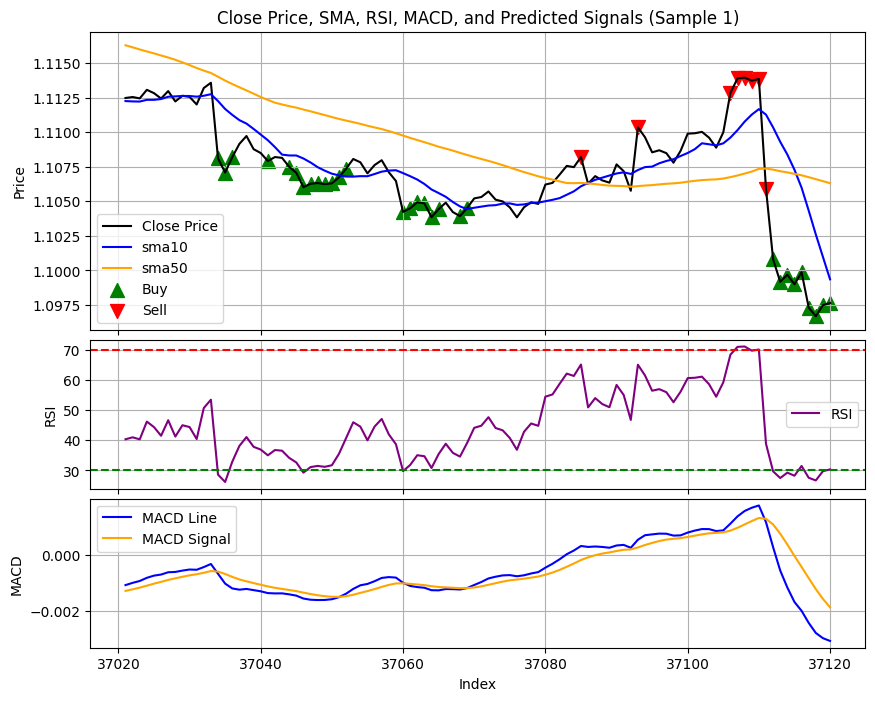

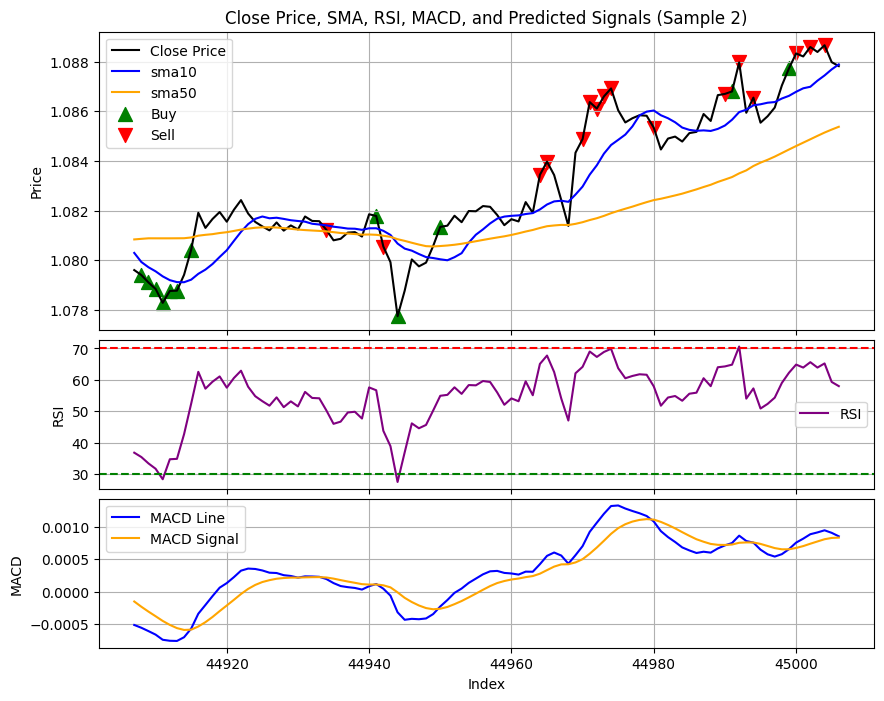

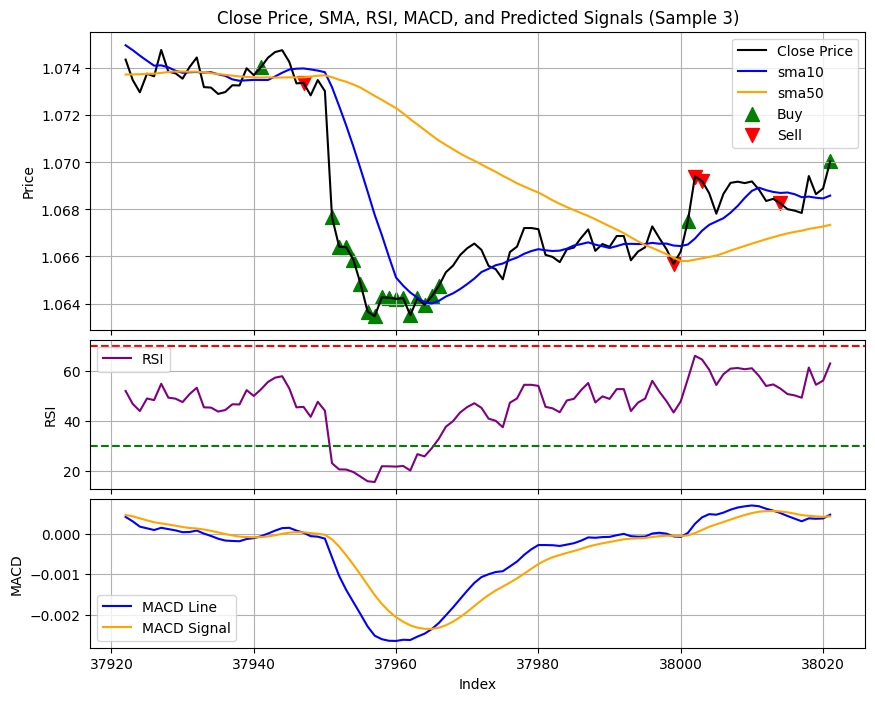

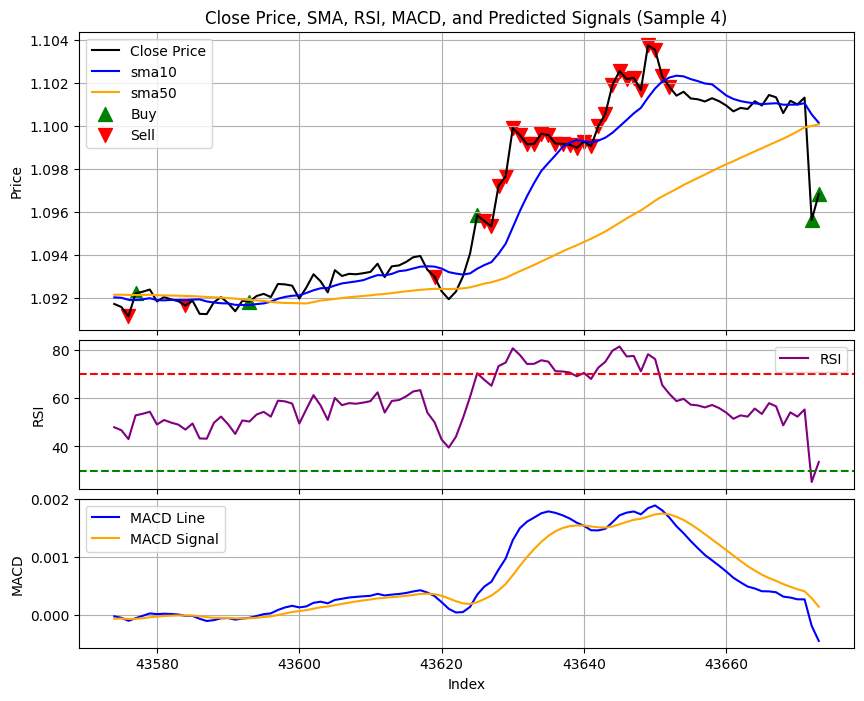

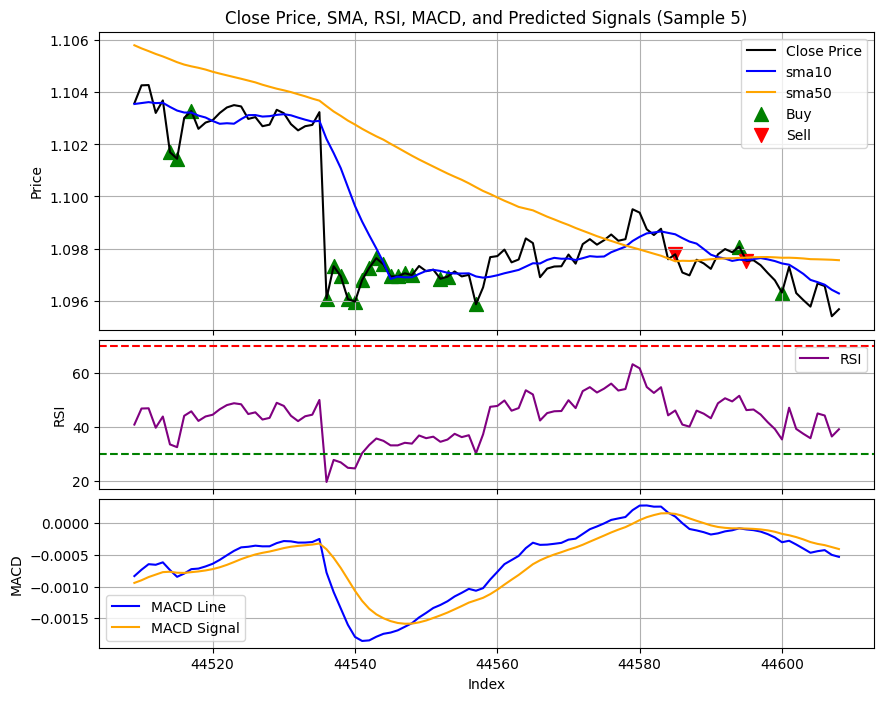

نمودارها برای داده‌های تست نمایش داده شدند.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def test_model_and_plot(data, X_test_scaled, y_test, model, scaler, features):
    """
    تابع برای رسم نمودارهای پیش‌بینی‌شده روی داده‌های تست
    
    پارامترها:
    - data: دیتافریم اصلی که شامل ستون‌های Close, RSI, sma10, و غیره است
    - X_test_scaled: داده‌های تست نرمال‌سازی‌شده
    - y_test: برچسب‌های واقعی تست
    - model: مدل آموزش‌دیده (MLP)
    - scaler: اسکیلری که برای نرمال‌سازی داده‌ها استفاده شده
    - features: لیست ویژگی‌ها
    """
    # پیش‌بینی سیگنال‌ها روی داده‌های تست
    predicted_signals = model.predict(X_test_scaled).argmax(axis=1)

    # بازگرداندن X_test_scaled به مقیاس اصلی برای تطبیق با داده‌های اصلی
    X_test_unscaled = scaler.inverse_transform(X_test_scaled)

    # تبدیل X_test_unscaled به دیتافریم برای تطبیق با data
    X_test_df = pd.DataFrame(X_test_unscaled, columns=features)

    # پیدا کردن اندیس‌های X_test در دیتافریم اصلی
    # فرض می‌کنیم X_test از data[features] استخراج شده و ترتیب اندیس‌ها حفظ شده است
    test_indices = data.index[-len(X_test_scaled):]  # اندیس‌های داده‌های تست (آخرین بخش داده‌ها)

    # ایجاد دیتافریم برای داده‌های تست با استفاده از اندیس‌ها
    test_data = data.loc[test_indices].copy()
    test_data['predicted_Signal'] = predicted_signals

    # انتخاب 5 دسته 100 تایی تصادفی از داده‌های تست
    max_start = len(test_data) - 100
    if max_start < 0:
        print("داده‌های تست کمتر از 100 نمونه دارند. کل داده‌ها نمایش داده می‌شوند.")
        subset = test_data
        random_starts = [0]
    else:
        random_starts = np.random.choice(range(max_start), size=5, replace=False)

    # رسم 5 نمودار
    for i, start in enumerate(random_starts):
        end = start + 100
        subset = test_data.iloc[start:end]

        # ایجاد زیرنمودارها (3 ردیف: قیمت، RSI، MACD)
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, 
                                             gridspec_kw={'height_ratios': [2, 1, 1], 'hspace': 0.05})

        # نمودار قیمت و SMA
        ax1.plot(subset.index, subset['Close'], label='Close Price', color='black')
        ax1.plot(subset.index, subset['sma10'], label='sma10', color='blue')
        ax1.plot(subset.index, subset['sma50'], label='sma50', color='orange')

        # رسم سیگنال‌های پیش‌بینی‌شده با مثلث
        buy_signals = subset[subset['predicted_Signal'] == 2]  # Buy
        sell_signals = subset[subset['predicted_Signal'] == 0]  # Sell

        ax1.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', label='Buy', s=100)
        ax1.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', label='Sell', s=100)

        ax1.set_title(f'Close Price, SMA, RSI, MACD, and Predicted Signals (Sample {i+1})')
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.grid(True)

        # نمودار RSI
        ax2.plot(subset.index, subset['RSI'], label='RSI', color='purple')
        ax2.axhline(y=70, color='red', linestyle='--')
        ax2.axhline(y=30, color='green', linestyle='--')
        ax2.set_ylabel('RSI')
        ax2.legend()
        ax2.grid(True)

        # نمودار MACD
        ax3.plot(subset.index, subset['macd_line'], label='MACD Line', color='blue')
        ax3.plot(subset.index, subset['macd_signal'], label='MACD Signal', color='orange')
        ax3.set_xlabel('Index')
        ax3.set_ylabel('MACD')
        ax3.legend()
        ax3.grid(True)

        plt.show()

    print("نمودارها برای داده‌های تست نمایش داده شدند.")

# فرض می‌کنیم داده‌ها و مدل آماده هستند
# مثال استفاده:
test_model_and_plot(data, X_test_scaled, y_test, model_manual_oversample, scaler, features)

In [36]:
features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 'macd_diff', 'sma_diff','MACD_Crossover_Buy', 'MACD_Crossover_Sell']

# features = ['RSI', 'sma10', 'sma50']
X = data[features]
y = data['Signal_Final']

# تقسیم داده‌ها به مجموعه آموزش و تست (80% آموزش، 20% تست)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)

In [47]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=5)
neigh.fit(X_train, y_train)

KNeighborsClassifier()

In [48]:
from sklearn.metrics import classification_report
y_pred = neigh.predict(X_test)
print("\nگزارش عملکرد مدل:")
print(classification_report(y_test, y_pred))


گزارش عملکرد مدل:
              precision    recall  f1-score   support

           0       0.62      0.76      0.68       867
           1       0.93      0.93      0.93      7784
           2       0.36      0.22      0.27       511

    accuracy                           0.87      9162
   macro avg       0.64      0.64      0.63      9162
weighted avg       0.87      0.87      0.87      9162



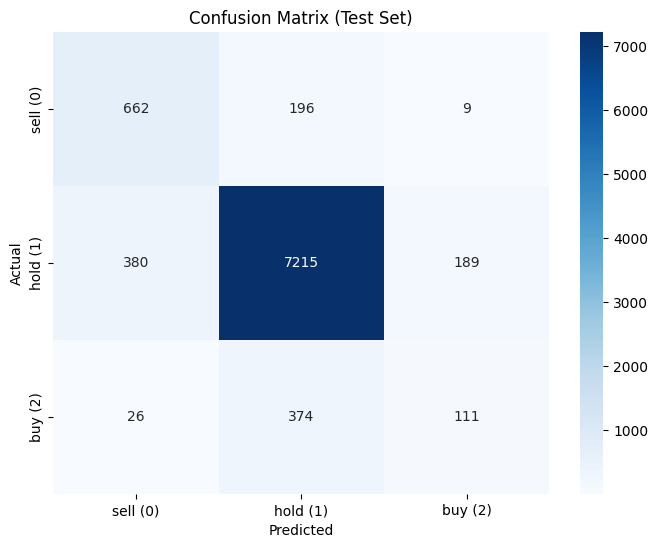

In [49]:
from sklearn.metrics import confusion_matrix
y_test_knn = neigh.predict(X_test)
cm = confusion_matrix(y_test, y_test_knn)

# رسم ماتریس درهم‌ریختگی
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['sell (0)', 'hold (1)', 'buy (2)'], 
            yticklabels=['sell (0)', 'hold (1)', 'buy (2)'])
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [47]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt

def test_model_and_plot(csv_path):
    # خواندن دیتاست از فایل CSV
    data = pd.read_csv(csv_path)

    # بررسی مقادیر نامعتبر در ستون Close
    if not data['Close'].replace([np.inf, -np.inf], np.nan).notnull().all():
        print("Warning: Invalid values (inf or NaN) found in 'Close' column. Replacing with NaN...")
        data['Close'].replace([np.inf, -np.inf], np.nan, inplace=True)

    data['RSI'] = ta.rsi(data['Close'], length=14)
    data['sma10'] = ta.sma(data['Close'], length=10)
    data['sma50'] = ta.sma(data['Close'], length=50)
    macd = ta.macd(data['Close'], fast=12, slow=26, Signal=9)
    data['macd_line'] = macd['MACD_12_26_9']
    data['macd_Signal'] = macd['MACDs_12_26_9']
    data['macd_diff'] = data['macd_line'] - data['macd_Signal']
    data['sma_diff'] = data['sma50'] - data['sma10']
    
    
    data['ATR'] = ta.atr(data['High'], data['Low'], data['Close'], length=14)
    bb = ta.bbands(data['Close'], length=20, std=2)
    data['BB_upper'] = bb['BBU_20_2.0']
    data['BB_lower'] = bb['BBL_20_2.0']
    data['BB_mid'] = bb['BBM_20_2.0']
    data['Close_lag1'] = data['Close'].shift(1)
    data['Close_lag2'] = data['Close'].shift(2)
    data.dropna(inplace=True)

    features = ['Close', 'Volume', 'RSI',
       'sma10', 'sma50', 'macd_line', 'macd_Signal', 'macd_diff', 'sma_diff',
       'ATR', 'BB_upper', 'BB_lower', 'BB_mid', 'Close_lag1', 'Close_lag2']
    
    X = data[features]

    # پیش‌بینی سیگنال‌ها
    data['predicted_Signal'] = xgb_model.predict(X)

    # انتخاب 5 دسته 100تایی متوالی به صورت رندوم
    max_start = len(data) - 100
    random_starts = np.random.choice(range(max_start), size=5, replace=False)

    # رسم 5 نمودار
    for i, start in enumerate(random_starts):
        end = start + 100
        subset = data.iloc[start:end]

        # ایجاد زیرنمودارها (3 ردیف: قیمت، RSI، MACD)
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, 
                                             gridspec_kw={'height_ratios': [2, 1, 1], 'hspace': 0.05})

        # نمودار قیمت و EMA
        ax1.plot(subset.index, subset['Close'], label='Close Price', color='black')
        ax1.plot(subset.index, subset['sma10'], label='sma10', color='blue')
        ax1.plot(subset.index, subset['sma50'], label='sma50', color='orange')

        # رسم سیگنال‌ها با مثلث
        buy_Signals = subset[subset['predicted_Signal'] == 2]  # Buy
        sell_Signals = subset[subset['predicted_Signal'] == 0]  # Sell

        ax1.scatter(buy_Signals.index, buy_Signals['Close'], marker='^', color='green', label='Buy', s=100)
        ax1.scatter(sell_Signals.index, sell_Signals['Close'], marker='v', color='red', label='Sell', s=100)

        ax1.set_title(f'Close Price, EMA, RSI, MACD, and Predicted Signals (Sample {i+1})')
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.grid(True)

        # نمودار RSI
        ax2.plot(subset.index, subset['RSI'], label='RSI', color='purple')
        ax2.axhline(y=70, color='red', linestyle='--')
        ax2.axhline(y=30, color='green', linestyle='--')
        ax2.set_ylabel('RSI')
        ax2.legend()
        ax2.grid(True)

        # نمودار MACD
        ax3.plot(subset.index, subset['macd_line'], label='MACD Line', color='blue')
        ax3.plot(subset.index, subset['macd_Signal'], label='MACD Signal', color='orange')
        ax3.set_xlabel('Index')
        ax3.set_ylabel('MACD')
        ax3.legend()
        ax3.grid(True)

        plt.show()


    print("Plots saved as 'Signal_plot_1.png' to 'Signal_plot_5.png'. You can download them from Kaggle output.")

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


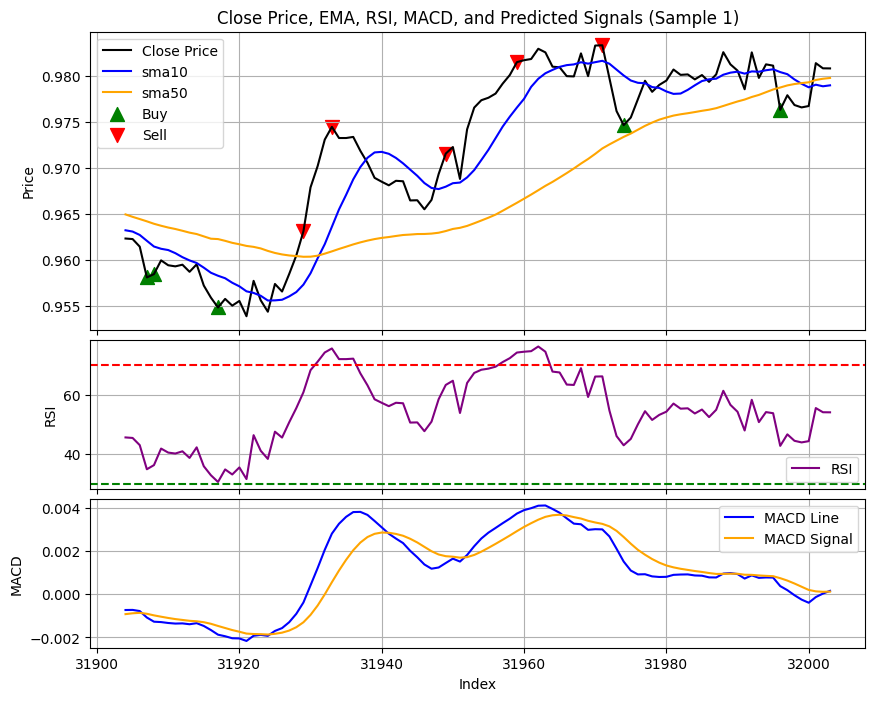

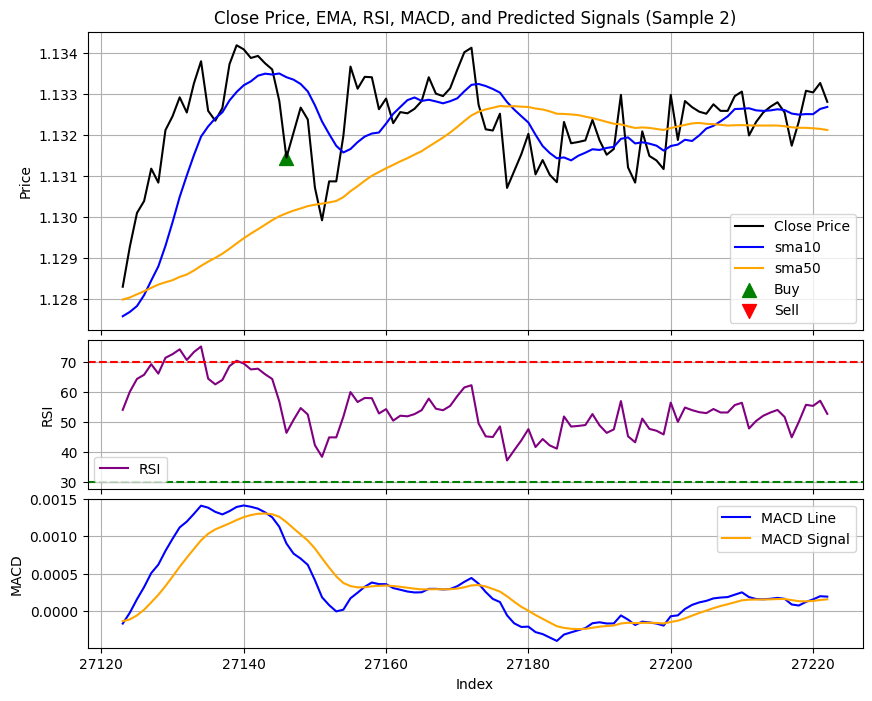

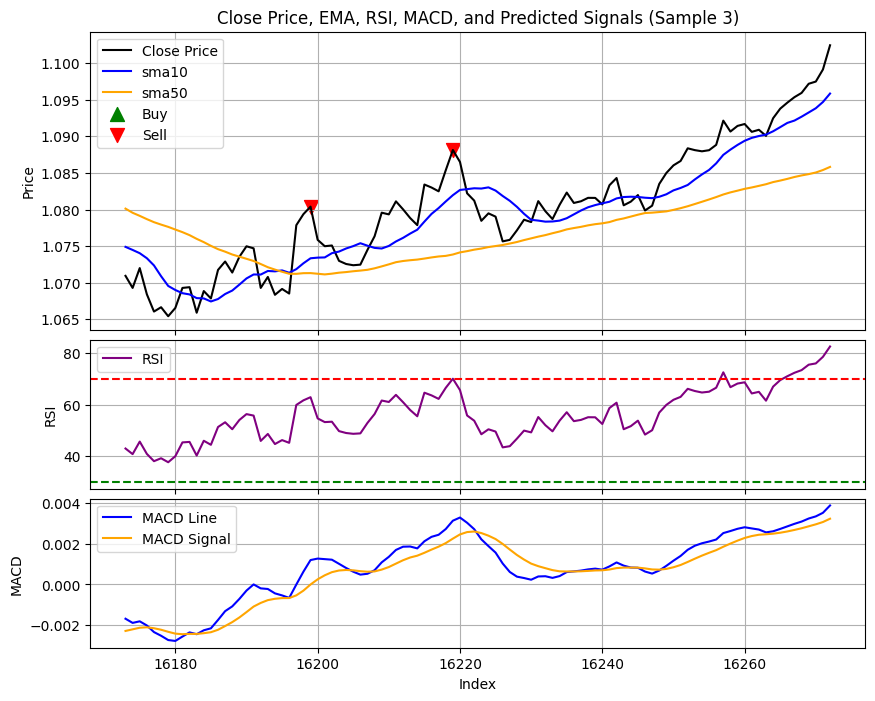

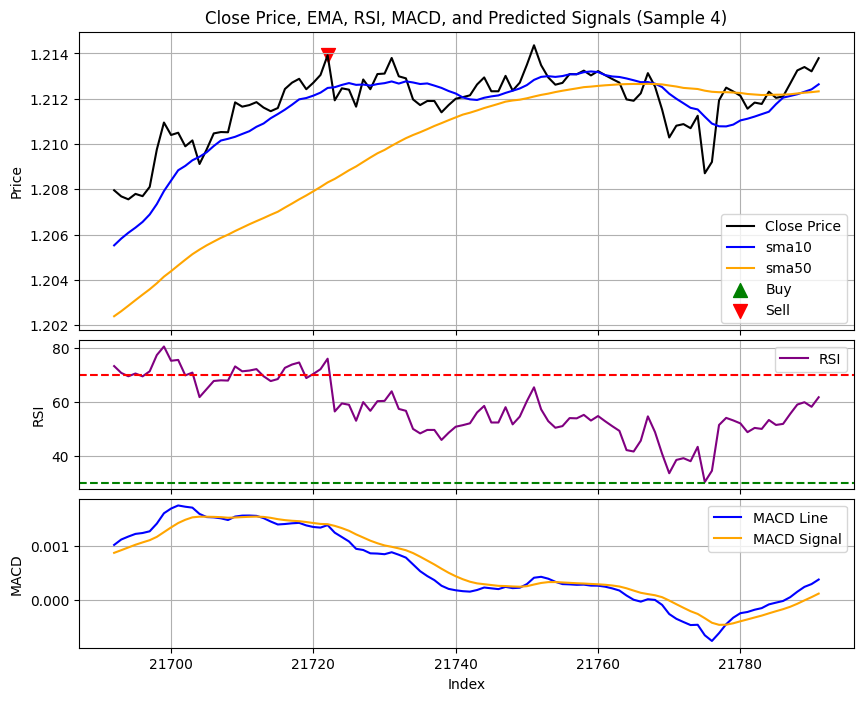

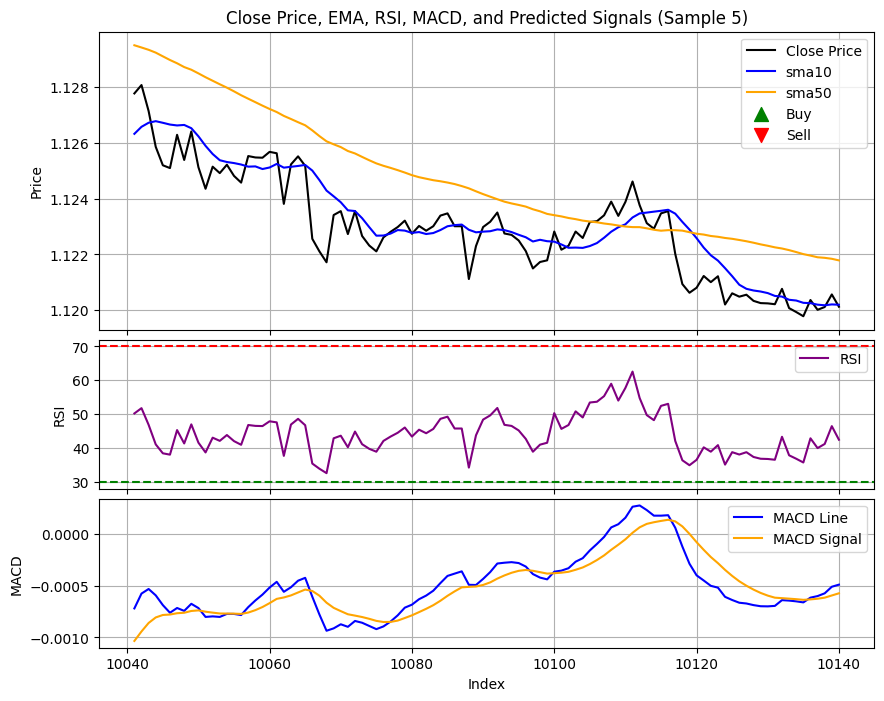

Plots saved as 'Signal_plot_1.png' to 'Signal_plot_5.png'. You can download them from Kaggle output.


In [48]:
test_model_and_plot('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')

XGBoost tree visualization saved as 'xgboost_tree3.png'


<Figure size 5000x1000 with 0 Axes>

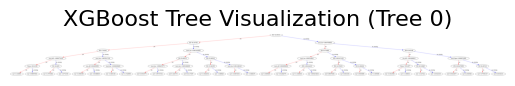

In [27]:
plt.figure(figsize=(50, 10))
xgb.plot_tree(xgb_model, num_trees=0, rankdir='TB')  # افزایش اندازه فونت
plt.title('XGBoost Tree Visualization (Tree 0)', fontsize=16)
plt.savefig('xgboost_tree3.png', dpi=1500, bbox_inches='tight')  # افزایش DPI و تنظیم حاشیه
print("XGBoost tree visualization saved as 'xgboost_tree3.png'")

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


توزیع سیگنال‌ها:
Signal
hold    38218
sell     3944
buy      3644
Name: count, dtype: int64

قوانین استخراج‌شده از Decision Tree:
|--- SMA50 <= 1.09
|   |--- SMA50 <= 1.05
|   |   |--- SMA10 <= 1.02
|   |   |   |--- Window_Volatility <= 0.01
|   |   |   |   |--- class: sell
|   |   |   |--- Window_Volatility >  0.01
|   |   |   |   |--- class: buy
|   |   |--- SMA10 >  1.02
|   |   |   |--- Window_Volatility <= 0.00
|   |   |   |   |--- class: sell
|   |   |   |--- Window_Volatility >  0.00
|   |   |   |   |--- class: sell
|   |--- SMA50 >  1.05
|   |   |--- SMA10 <= 1.08
|   |   |   |--- SMA10 <= 1.06
|   |   |   |   |--- class: buy
|   |   |   |--- SMA10 >  1.06
|   |   |   |   |--- class: sell
|   |   |--- SMA10 >  1.08
|   |   |   |--- SMA50 <= 1.08
|   |   |   |   |--- class: buy
|   |   |   |--- SMA50 >  1.08
|   |   |   |   |--- class: buy
|--- SMA50 >  1.09
|   |--- Window_Volatility <= 0.01
|   |   |--- SMA50 <= 1.24
|   |   |   |--- SMA10 <= 1.11
|   |   |   |   |--- class: s

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


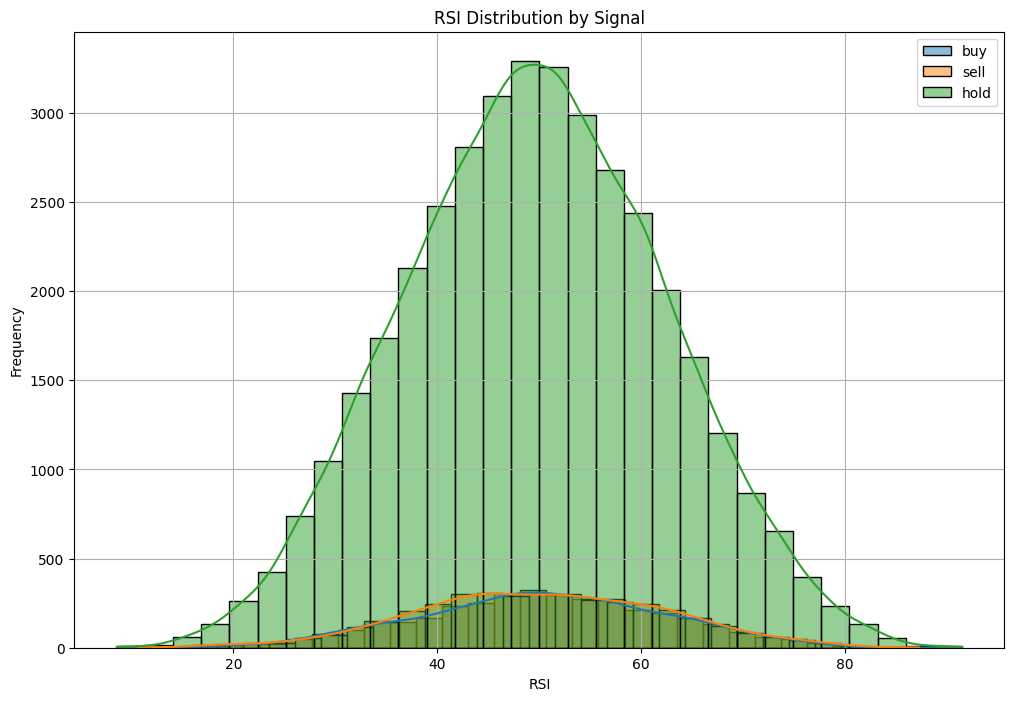

In [25]:
import pandas as pd
import numpy as np
import pandas_ta as ta
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import export_text
import matplotlib.pyplot as plt
import seaborn as sns

# فرض می‌کنیم داده‌ها لود شده‌اند
# data = pd.read_csv('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')

# 1. ایجاد ستون Signal بر اساس حداکثر/حداقل قیمت در 10 کندل آینده
window_size = 10
profit_threshold = 0.005  # آستانه 0.5%

# محاسبه حداکثر High و حداقل Low در 10 کندل آینده
data['Future_Max_High'] = data['High'].rolling(window=window_size, closed='right').max().shift(-window_size)
data['Future_Min_Low'] = data['Low'].rolling(window=window_size, closed='right').min().shift(-window_size)

# محاسبه تغییرات نسبی
data['Max_High_Diff'] = (data['Future_Max_High'] - data['Close']) / data['Close']
data['Min_Low_Diff'] = (data['Future_Min_Low'] - data['Close']) / data['Close']

# تعریف سیگنال‌ها
data['Signal'] = 'hold'
data.loc[data['Max_High_Diff'] >= profit_threshold, 'Signal'] = 'buy'
data.loc[data['Min_Low_Diff'] <= -profit_threshold, 'Signal'] = 'sell'

# 2. حذف ردیف‌های NaN
data_clean = data.dropna(subset=['Max_High_Diff', 'Min_Low_Diff', 'Signal']).copy()

# 3. اضافه کردن ویژگی‌های مبتنی بر گذشته و فعلی
data_clean['RSI'] = ta.rsi(data_clean['Close'], length=14)
data_clean['SMA10'] = ta.sma(data_clean['Close'], length=10)
data_clean['SMA50'] = ta.sma(data_clean['Close'], length=50)
macd = ta.macd(data_clean['Close'], fast=12, slow=26, signal=9)
data_clean['MACD_line'] = macd['MACD_12_26_9']
data_clean['MACD_signal'] = macd['MACDs_12_26_9']
data_clean['MACD_diff'] = data_clean['MACD_line'] - data_clean['MACD_signal']

# ویژگی‌های قیمتی
data_clean['Price_Position'] = (data_clean['Close'] - data_clean['Low'].rolling(window=10).min()) / (data_clean['High'].rolling(window=10).max() - data_clean['Low'].rolling(window=10).min())
data_clean['Bullish_Candles'] = (data_clean['Close'] > data_clean['Open']).rolling(window=10).sum()
data_clean['Bearish_Candles'] = (data_clean['Close'] < data_clean['Open']).rolling(window=10).sum()
data_clean['Window_Volatility'] = (data_clean['High'].rolling(window=10).max() - data_clean['Low'].rolling(window=10).min()) / data_clean['Close'].rolling(window=10).mean()

# حذف NaNهای ناشی از ویژگی‌ها
data_clean = data_clean.dropna()

# 4. نمایش توزیع سیگنال‌ها
signal_counts = data_clean['Signal'].value_counts()
print("توزیع سیگنال‌ها:")
print(signal_counts)

# 5. آماده‌سازی داده‌ها برای مدل
features = ['RSI', 'SMA10', 'SMA50', 'MACD_diff', 'Price_Position', 'Bullish_Candles', 'Bearish_Candles', 'Window_Volatility']
X = data_clean[features]
y = data_clean['Signal']

# تقسیم داده‌ها به آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 6. آموزش مدل Decision Tree با وزن‌دهی به کلاس‌ها
# محاسبه وزن کلاس‌ها برای مدیریت عدم توازن
class_weights = {
    'buy': len(y_train) / (3 * y_train.value_counts().get('buy', 1)),
    'sell': len(y_train) / (3 * y_train.value_counts().get('sell', 1)),
    'hold': len(y_train) / (3 * y_train.value_counts().get('hold', 1))
}
tree = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight=class_weights)
tree.fit(X_train, y_train)

# 7. استخراج قوانین
rules = export_text(tree, feature_names=features)
print("\nقوانین استخراج‌شده از Decision Tree:")
print(rules)

# 8. ارزیابی مدل
y_pred = tree.predict(X_test)
print("\nگزارش عملکرد مدل روی داده‌های تست:")
print(classification_report(y_test, y_pred))

# 9. رسم هیستوگرام RSI برای هر سیگنال
plt.figure(figsize=(12, 8))
for signal in ['buy', 'sell', 'hold']:
    signal_data = data_clean[data_clean['Signal'] == signal]
    sns.histplot(signal_data['RSI'], bins=30, kde=True, label=signal, alpha=0.5)
plt.title('RSI Distribution by Signal')
plt.xlabel('RSI')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt

def test_model_and_plot(csv_path):
    # خواندن دیتاست از فایل CSV
    data = pd.read_csv(csv_path)

    # بررسی مقادیر نامعتبر در ستون Close
    if not data['Close'].replace([np.inf, -np.inf], np.nan).notnull().all():
        print("Warning: Invalid values (inf or NaN) found in 'Close' column. Replacing with NaN...")
        data['Close'].replace([np.inf, -np.inf], np.nan, inplace=True)

    data['RSI'] = ta.rsi(data['Close'], length=14)
    data['sma10'] = ta.sma(data['Close'], length=10)
    data['sma50'] = ta.sma(data['Close'], length=50)
    macd = ta.macd(data['Close'], fast=12, slow=26, Signal=9)
    data['macd_line'] = macd['MACD_12_26_9']
    data['macd_Signal'] = macd['MACDs_12_26_9']
    data['macd_diff'] = data['macd_line'] - data['macd_Signal']
    data['sma_diff'] = data['sma50'] - data['sma10']
    

    window_size = 10
    profit_threshold = 0.001  # آستانه 0.5%
    
    # محاسبه حداکثر High و حداقل Low در 10 کندل آینده
    data['Future_Max_High'] = data['High'].rolling(window=window_size, closed='right').max().shift(-window_size)
    data['Future_Min_Low'] = data['Low'].rolling(window=window_size, closed='right').min().shift(-window_size)
    
    # محاسبه تغییرات نسبی
    data['Max_High_Diff'] = (data['Future_Max_High'] - data['Close']) / data['Close']
    data['Min_Low_Diff'] = (data['Future_Min_Low'] - data['Close']) / data['Close']
    
    # تعریف سیگنال‌ها
    data['Signal'] = 'hold'
    data.loc[data['Max_High_Diff'] >= profit_threshold, 'Signal'] = 'buy'
    data.loc[data['Min_Low_Diff'] <= -profit_threshold, 'Signal'] = 'sell'

    data.dropna(inplace=True)



    # انتخاب 5 دسته 100تایی متوالی به صورت رندوم
    max_start = len(data) - 100
    random_starts = np.random.choice(range(max_start), size=5, replace=False)

    # رسم 5 نمودار
    for i, start in enumerate(random_starts):
        end = start + 100
        subset = data.iloc[start:end]

        # ایجاد زیرنمودارها (3 ردیف: قیمت، RSI، MACD)
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, 
                                             gridspec_kw={'height_ratios': [2, 1, 1], 'hspace': 0.05})

        # نمودار قیمت و EMA
        ax1.plot(subset.index, subset['Close'], label='Close Price', color='black')
        ax1.plot(subset.index, subset['sma10'], label='sma10', color='blue')
        ax1.plot(subset.index, subset['sma50'], label='sma50', color='orange')

        # رسم سیگنال‌ها با مثلث
        buy_Signals = subset[subset['Signal'] == 'buy']  # Buy
        sell_Signals = subset[subset['Signal'] == 'sell']  # Sell

        ax1.scatter(buy_Signals.index, buy_Signals['Close'], marker='^', color='green', label='Buy', s=100)
        ax1.scatter(sell_Signals.index, sell_Signals['Close'], marker='v', color='red', label='Sell', s=100)

        ax1.set_title(f'Close Price, EMA, RSI, MACD, and Predicted Signals (Sample {i+1})')
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.grid(True)

        # نمودار RSI
        ax2.plot(subset.index, subset['RSI'], label='RSI', color='purple')
        ax2.axhline(y=70, color='red', linestyle='--')
        ax2.axhline(y=30, color='green', linestyle='--')
        ax2.set_ylabel('RSI')
        ax2.legend()
        ax2.grid(True)

        # نمودار MACD
        ax3.plot(subset.index, subset['macd_line'], label='MACD Line', color='blue')
        ax3.plot(subset.index, subset['macd_Signal'], label='MACD Signal', color='orange')
        ax3.set_xlabel('Index')
        ax3.set_ylabel('MACD')
        ax3.legend()
        ax3.grid(True)

        plt.show()


    print("Plots saved as 'Signal_plot_1.png' to 'Signal_plot_5.png'. You can download them from Kaggle output.")

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)


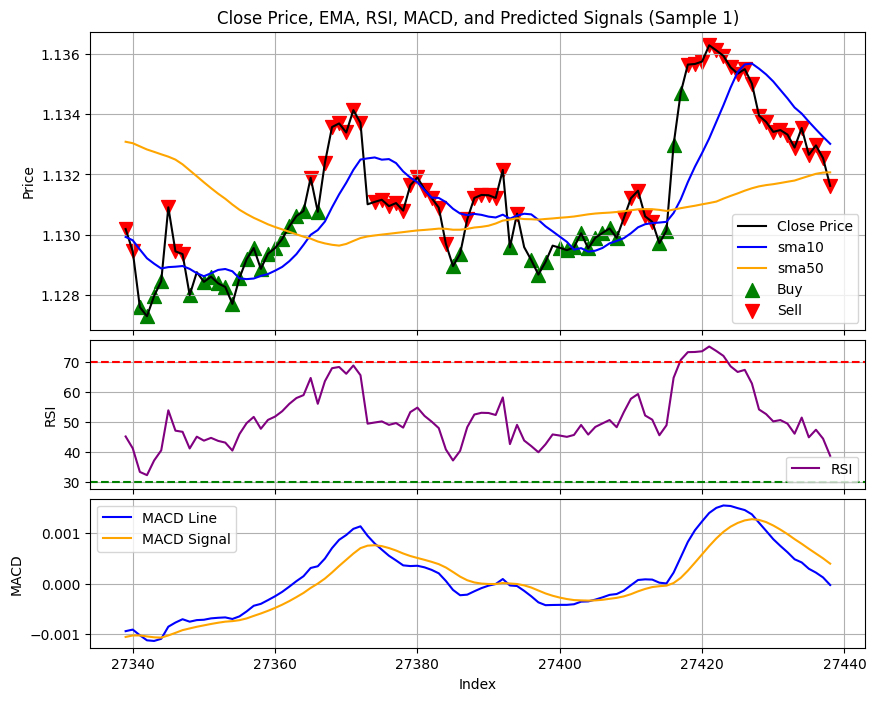

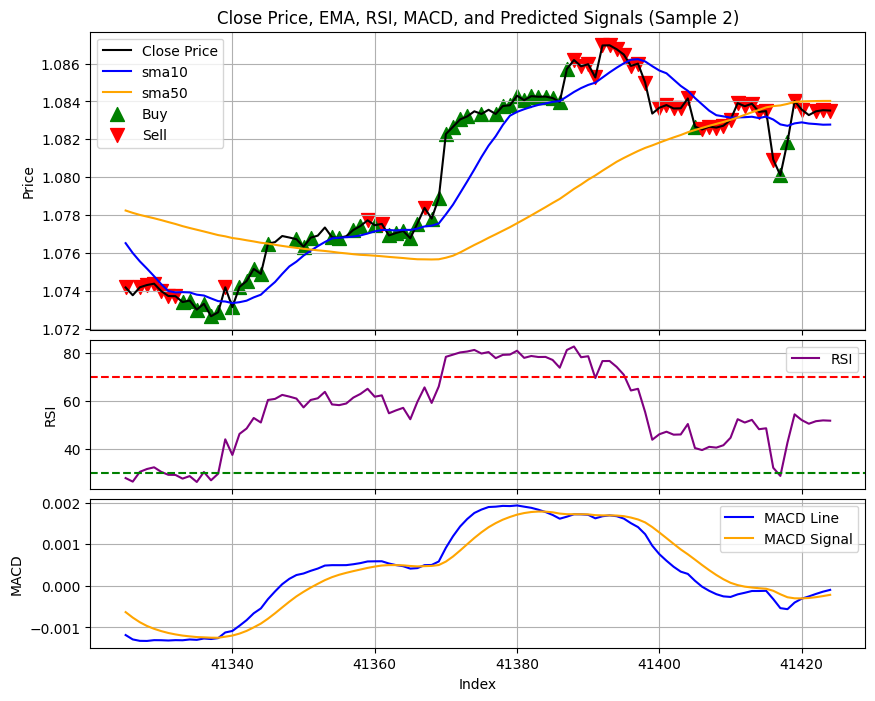

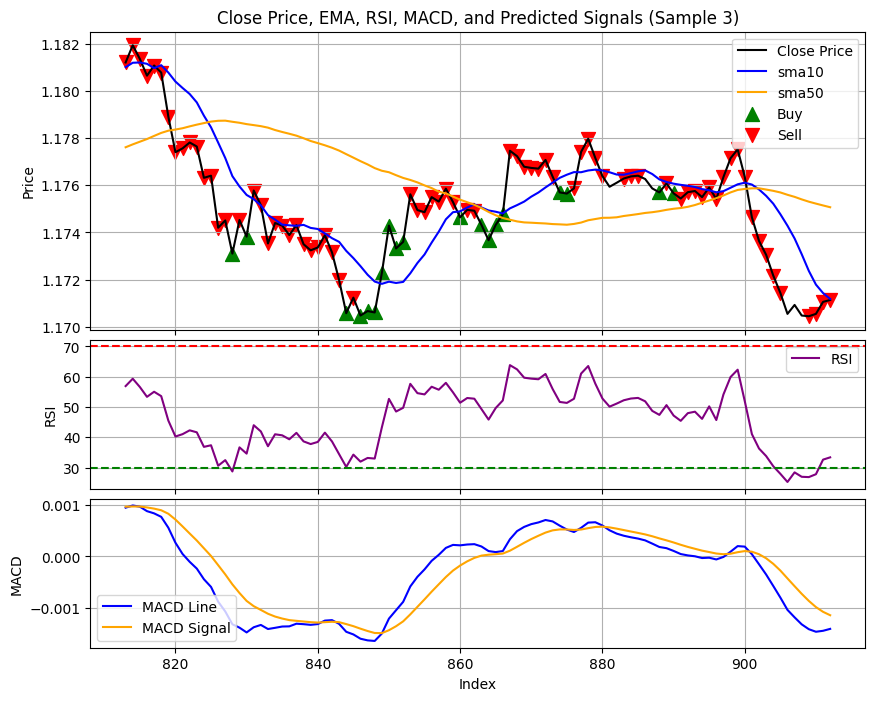

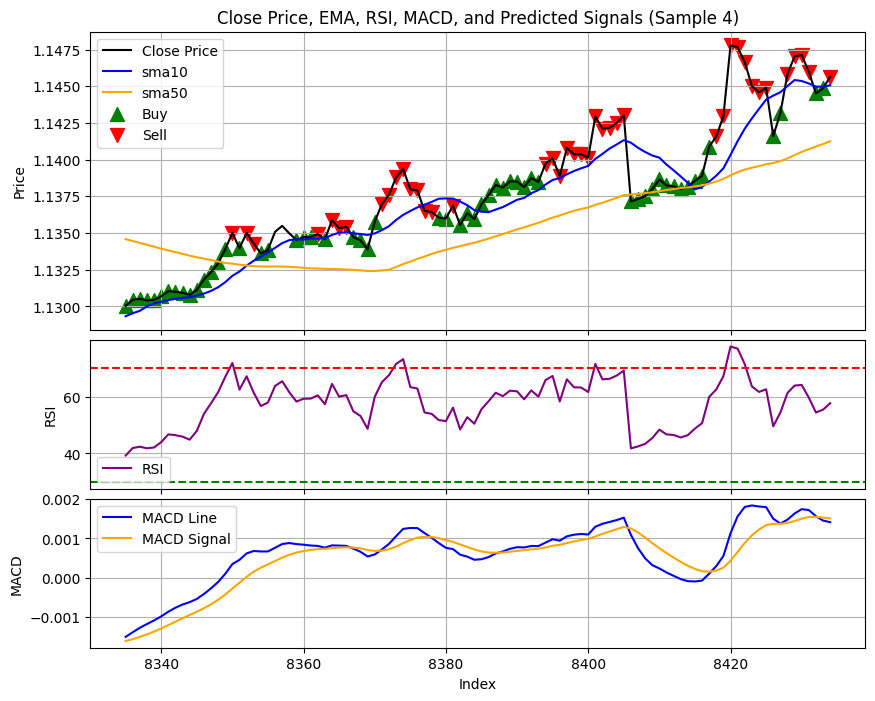

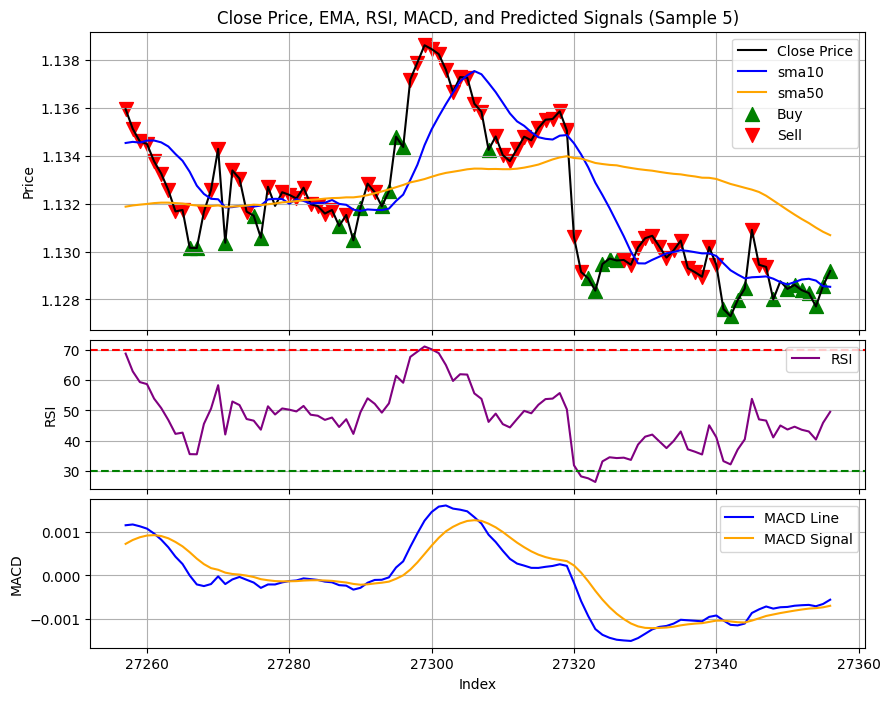

Plots saved as 'Signal_plot_1.png' to 'Signal_plot_5.png'. You can download them from Kaggle output.


In [41]:
test_model_and_plot('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressio

توزیع سیگنال‌های عادی (Signal_Threshold):
Signal_Threshold
sell    29101
buy     14035
hold     2670
Name: count, dtype: int64

توزیع سیگنال‌های نهایی (Signal_Final):
Signal_Final
hold    38759
sell     4669
buy      2378
Name: count, dtype: int64


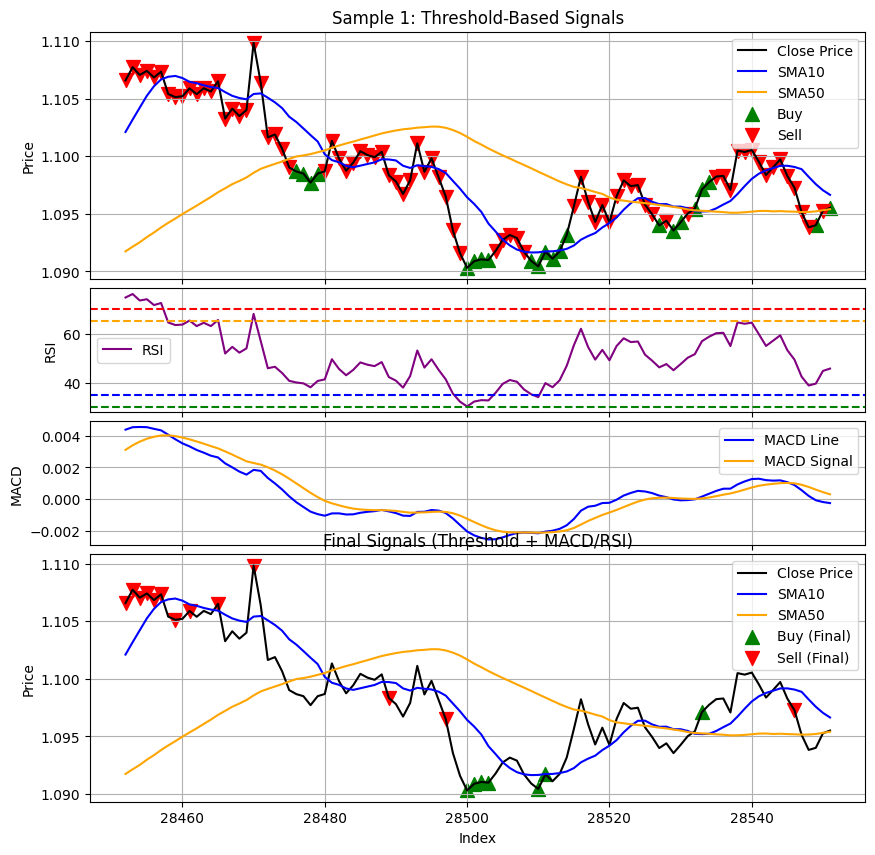

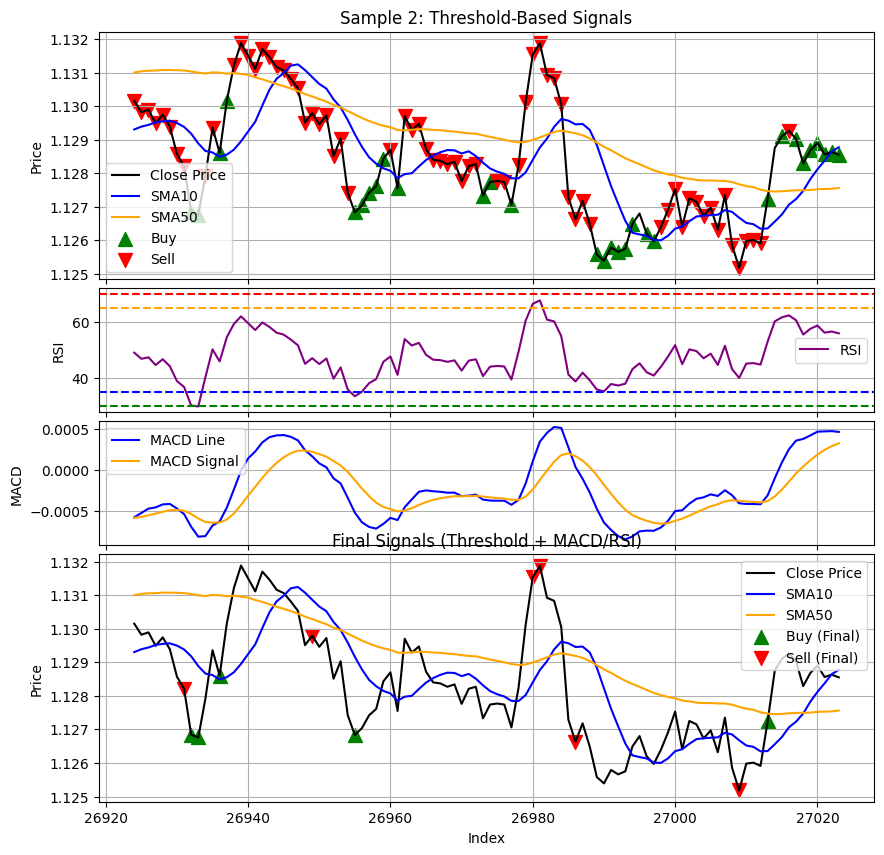

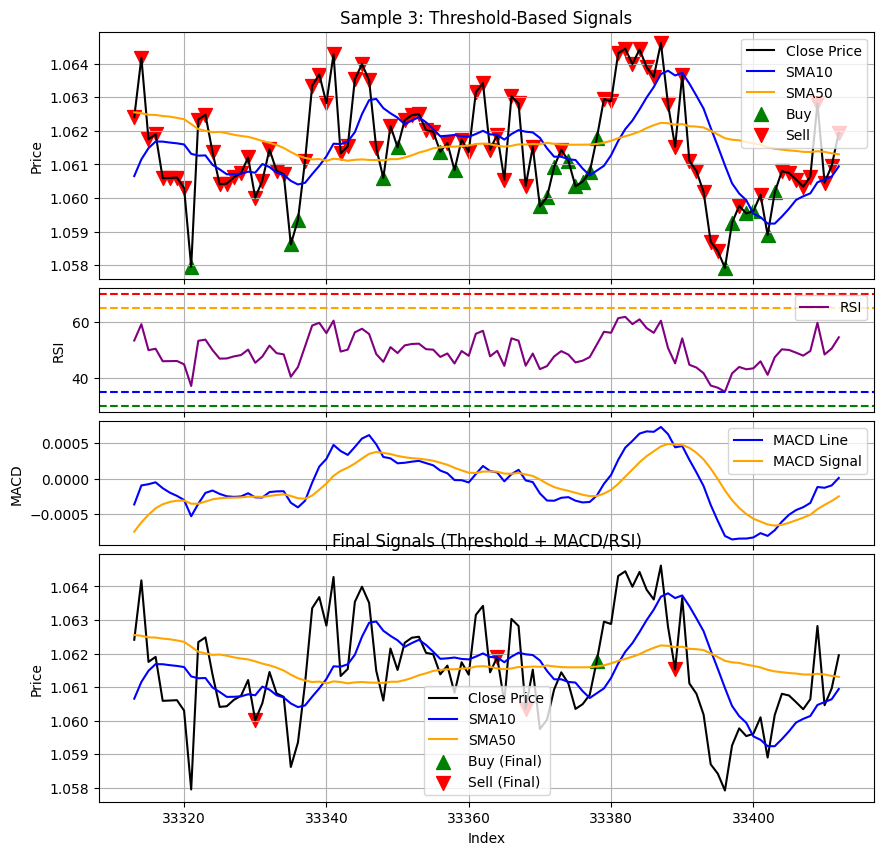

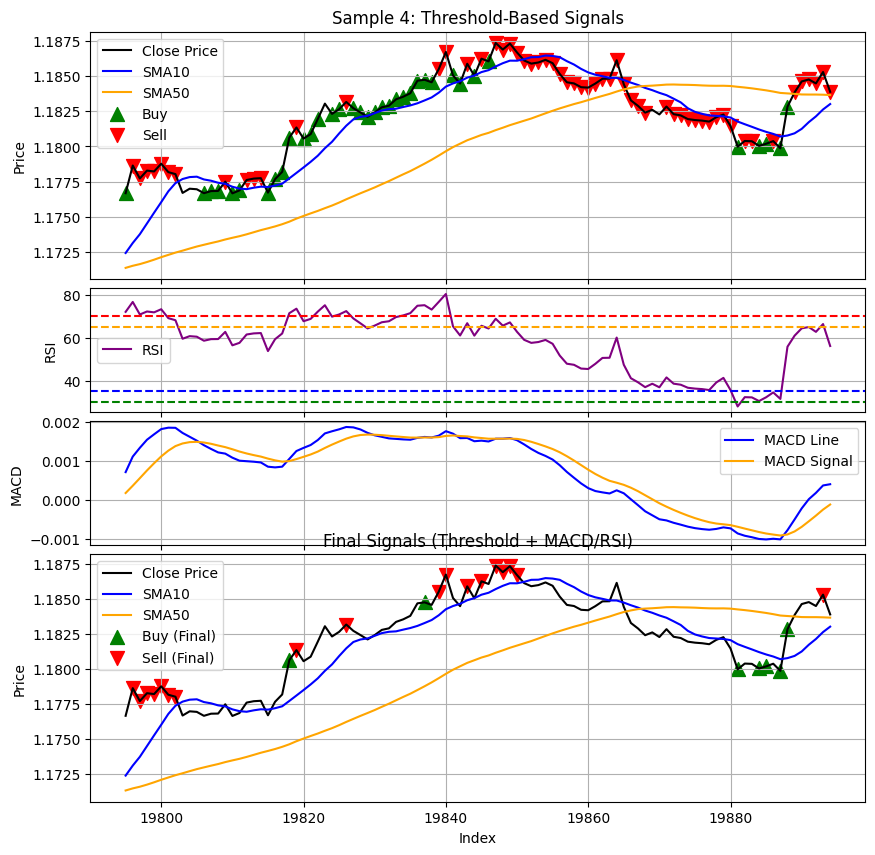

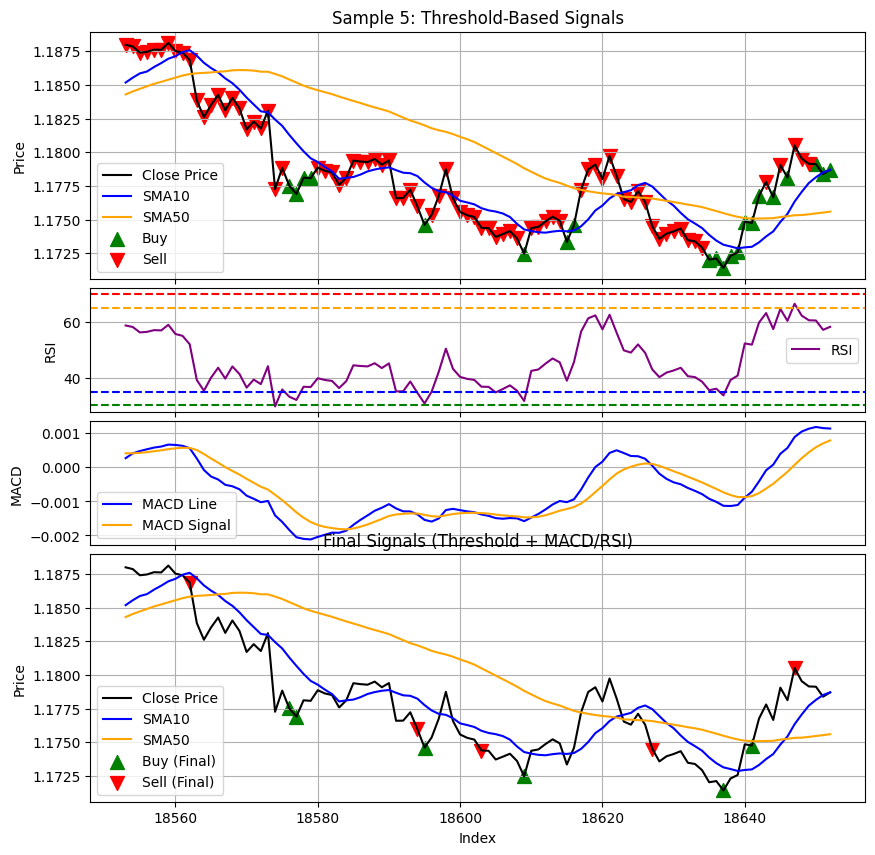

5 فیگور برای نمونه‌های تصادفی نمایش داده شدند.


In [43]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns

def test_model_and_plot(csv_path):
    # خواندن دیتاست
    data = pd.read_csv(csv_path)

    # بررسی مقادیر نامعتبر در ستون Close
    if not data['Close'].replace([np.inf, -np.inf], np.nan).notnull().all():
        print("Warning: Invalid values (inf or NaN) found in 'Close' column. Replacing with NaN...")
        data['Close'].replace([np.inf, -np.inf], np.nan, inplace=True)

    # محاسبه اندیکاتورها
    data['RSI'] = ta.rsi(data['Close'], length=14)
    data['sma10'] = ta.sma(data['Close'], length=10)
    data['sma50'] = ta.sma(data['Close'], length=50)
    macd = ta.macd(data['Close'], fast=12, slow=26, signal=9)
    data['macd_line'] = macd['MACD_12_26_9']
    data['macd_signal'] = macd['MACDs_12_26_9']
    data['macd_diff'] = data['macd_line'] - data['macd_signal']
    data['sma_diff'] = data['sma50'] - data['sma10']

    # پارامترها
    window_size = 10
    profit_threshold = 0.001  # آستانه 0.1%

    # محاسبه حداکثر High و حداقل Low در 10 کندل آینده
    data['Future_Max_High'] = data['High'].rolling(window=window_size, closed='right').max().shift(-window_size)
    data['Future_Min_Low'] = data['Low'].rolling(window=window_size, closed='right').min().shift(-window_size)

    # محاسبه تغییرات نسبی
    data['Max_High_Diff'] = (data['Future_Max_High'] - data['Close']) / data['Close']
    data['Min_Low_Diff'] = (data['Future_Min_Low'] - data['Close']) / data['Close']

    # 1. سیگنال‌های عادی (فقط بر اساس آستانه)
    data['Signal_Threshold'] = 'hold'
    data.loc[data['Max_High_Diff'] >= profit_threshold, 'Signal_Threshold'] = 'buy'
    data.loc[data['Min_Low_Diff'] <= -profit_threshold, 'Signal_Threshold'] = 'sell'

    # 2. تشخیص تقاطع MACD
    data['MACD_Crossover_Buy'] = (data['macd_line'] > data['macd_signal']) & (data['macd_line'].shift(1) < data['macd_signal'].shift(1))
    data['MACD_Crossover_Sell'] = (data['macd_line'] < data['macd_signal']) & (data['macd_line'].shift(1) > data['macd_signal'].shift(1))

    # 3. سیگنال‌های نهایی (آستانه + MACD Crossover یا RSI)
    data['Signal_Final'] = 'hold'
    buy_condition = (data['Signal_Threshold'] == 'buy') & ((data['MACD_Crossover_Buy']) | (data['RSI'] < 35))
    sell_condition = (data['Signal_Threshold'] == 'sell') & ((data['MACD_Crossover_Sell']) | (data['RSI'] > 65))
    data.loc[buy_condition, 'Signal_Final'] = 'buy'
    data.loc[sell_condition, 'Signal_Final'] = 'sell'

    # حذف NaNها
    data.dropna(inplace=True)

    # نمایش توزیع سیگنال‌ها
    print("توزیع سیگنال‌های عادی (Signal_Threshold):")
    print(data['Signal_Threshold'].value_counts())
    print("\nتوزیع سیگنال‌های نهایی (Signal_Final):")
    print(data['Signal_Final'].value_counts())

    # انتخاب 5 دسته 100 تایی تصادفی
    max_start = len(data) - 100
    random_starts = np.random.choice(range(max_start), size=5, replace=False)

    # رسم 5 فیگور
    for i, start in enumerate(random_starts):
        end = start + 100
        subset = data.iloc[start:end]

        # ایجاد زیرنمودارها (4 ردیف: قیمت با Signal_Threshold، RSI، MACD، قیمت با Signal_Final)
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 10), sharex=True, 
                                                 gridspec_kw={'height_ratios': [2, 1, 1, 2], 'hspace': 0.05})

        # محور 1: قیمت و سیگنال‌های عادی
        ax1.plot(subset.index, subset['Close'], label='Close Price', color='black')
        ax1.plot(subset.index, subset['sma10'], label='SMA10', color='blue')
        ax1.plot(subset.index, subset['sma50'], label='SMA50', color='orange')
        buy_signals = subset[subset['Signal_Threshold'] == 'buy']
        sell_signals = subset[subset['Signal_Threshold'] == 'sell']
        ax1.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', label='Buy', s=100)
        ax1.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', label='Sell', s=100)
        ax1.set_title(f'Sample {i+1}: Threshold-Based Signals')
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.grid(True)

        # محور 2: RSI
        ax2.plot(subset.index, subset['RSI'], label='RSI', color='purple')
        ax2.axhline(y=70, color='red', linestyle='--')
        ax2.axhline(y=30, color='green', linestyle='--')
        ax2.axhline(y=65, color='orange', linestyle='--')
        ax2.axhline(y=35, color='blue', linestyle='--')
        ax2.set_ylabel('RSI')
        ax2.legend()
        ax2.grid(True)

        # محور 3: MACD
        ax3.plot(subset.index, subset['macd_line'], label='MACD Line', color='blue')
        ax3.plot(subset.index, subset['macd_signal'], label='MACD Signal', color='orange')
        ax3.set_ylabel('MACD')
        ax3.legend()
        ax3.grid(True)

        # محور 4: قیمت و سیگنال‌های نهایی
        ax4.plot(subset.index, subset['Close'], label='Close Price', color='black')
        ax4.plot(subset.index, subset['sma10'], label='SMA10', color='blue')
        ax4.plot(subset.index, subset['sma50'], label='SMA50', color='orange')
        buy_signals_final = subset[subset['Signal_Final'] == 'buy']
        sell_signals_final = subset[subset['Signal_Final'] == 'sell']
        ax4.scatter(buy_signals_final.index, buy_signals_final['Close'], marker='^', color='green', label='Buy (Final)', s=100)
        ax4.scatter(sell_signals_final.index, sell_signals_final['Close'], marker='v', color='red', label='Sell (Final)', s=100)
        ax4.set_title('Final Signals (Threshold + MACD/RSI)')
        ax4.set_xlabel('Index')
        ax4.set_ylabel('Price')
        ax4.legend()
        ax4.grid(True)

        plt.tight_layout()
        plt.show()

    print("5 فیگور برای نمونه‌های تصادفی نمایش داده شدند.")

# اجرای تابع
test_model_and_plot('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')

In [ ]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt

def test_model_and_plot(csv_path,model):
    # خواندن دیتاست از فایل CSV
    data = pd.read_csv(csv_path)

    # بررسی مقادیر نامعتبر در ستون Close
    if not data['Close'].replace([np.inf, -np.inf], np.nan).notnull().all():
        print("Warning: Invalid values (inf or NaN) found in 'Close' column. Replacing with NaN...")
        data['Close'].replace([np.inf, -np.inf], np.nan, inplace=True)

    data['RSI'] = ta.rsi(data['Close'], length=14)
    data['sma10'] = ta.sma(data['Close'], length=10)
    data['sma50'] = ta.sma(data['Close'], length=50)
    macd = ta.macd(data['Close'], fast=12, slow=26, signal=9)
    data['macd_line'] = macd['MACD_12_26_9']
    data['macd_signal'] = macd['MACDs_12_26_9']
    data['macd_diff'] = data['macd_line'] - data['macd_signal']
    data['sma_diff'] = data['sma50'] - data['sma10']
    
        # پارامترها
    window_size = 10
    profit_threshold = 0.001  # آستانه 0.1%
    
        # محاسبه حداکثر High و حداقل Low در 10 کندل آینده
    data['Future_Max_High'] = data['High'].rolling(window=window_size, closed='right').max().shift(-window_size)
    data['Future_Min_Low'] = data['Low'].rolling(window=window_size, closed='right').min().shift(-window_size)
    
        # محاسبه تغییرات نسبی
    data['Max_High_Diff'] = (data['Future_Max_High'] - data['Close']) / data['Close']
    data['Min_Low_Diff'] = (data['Future_Min_Low'] - data['Close']) / data['Close']
    
        # 1. سیگنال‌های عادی (فقط بر اساس آستانه)
    data['Signal_Threshold'] = 'hold'
    data.loc[data['Max_High_Diff'] >= profit_threshold, 'Signal_Threshold'] = 'buy'
    data.loc[data['Min_Low_Diff'] <= -profit_threshold, 'Signal_Threshold'] = 'sell'
    
        # 2. تشخیص تقاطع MACD
    data['MACD_Crossover_Buy'] = (data['macd_line'] > data['macd_signal']) & (data['macd_line'].shift(1) < data['macd_signal'].shift(1))
    data['MACD_Crossover_Sell'] = (data['macd_line'] < data['macd_signal']) & (data['macd_line'].shift(1) > data['macd_signal'].shift(1))
    
        # حذف NaNها
    data.dropna(inplace=True)

    features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 'macd_diff', 'sma_diff','MACD_Crossover_Buy', 'MACD_Crossover_Sell']

    # features = ['RSI', 'sma10', 'sma50']
    X = data[features]

    # پیش‌بینی سیگنال‌ها
    data['predicted_Signal'] = model.predict(X)

    # انتخاب 5 دسته 100تایی متوالی به صورت رندوم
    max_start = len(data) - 100
    random_starts = np.random.choice(range(max_start), size=5, replace=False)

    # رسم 5 نمودار
    for i, start in enumerate(random_starts):
        end = start + 100
        subset = data.iloc[start:end]

        # ایجاد زیرنمودارها (3 ردیف: قیمت، RSI، MACD)
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, 
                                             gridspec_kw={'height_ratios': [2, 1, 1], 'hspace': 0.05})

        # نمودار قیمت و EMA
        ax1.plot(subset.index, subset['Close'], label='Close Price', color='black')
        ax1.plot(subset.index, subset['sma10'], label='sma10', color='blue')
        ax1.plot(subset.index, subset['sma50'], label='sma50', color='orange')

        # رسم سیگنال‌ها با مثلث
        buy_Signals = subset[subset['predicted_Signal'] == 2]  # Buy
        sell_Signals = subset[subset['predicted_Signal'] == 0]  # Sell

        ax1.scatter(buy_Signals.index, buy_Signals['Close'], marker='^', color='green', label='Buy', s=100)
        ax1.scatter(sell_Signals.index, sell_Signals['Close'], marker='v', color='red', label='Sell', s=100)

        ax1.set_title(f'Close Price, EMA, RSI, MACD, and Predicted Signals (Sample {i+1})')
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.grid(True)

        # نمودار RSI
        ax2.plot(subset.index, subset['RSI'], label='RSI', color='purple')
        ax2.axhline(y=70, color='red', linestyle='--')
        ax2.axhline(y=30, color='green', linestyle='--')
        ax2.set_ylabel('RSI')
        ax2.legend()
        ax2.grid(True)

        # نمودار MACD
        ax3.plot(subset.index, subset['macd_line'], label='MACD Line', color='blue')
        ax3.plot(subset.index, subset['macd_signal'], label='MACD Signal', color='orange')
        ax3.set_xlabel('Index')
        ax3.set_ylabel('MACD')
        ax3.legend()
        ax3.grid(True)

        plt.show()


    print("Plots saved as 'Signal_plot_1.png' to 'Signal_plot_5.png'. You can download them from Kaggle output.")

In [ ]:
test_model_and_plot('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv',model)